 <center> <h1> <b> Pattern Recognition and Machine Learning (EE2802 - AI2000) </b> </h1> </center>

<b> Programming Assignment - 03 : Classification</b>


This programming assignment offers you an opportunity to implement various linear classification models. You'll begin with straightforward algorithms like Least Squares classification, LDA, and FDA. Subsequently, you'll delve into implementing the perceptron algorithm. Lastly, you'll tackle probabilistic approaches for classification. To deepen your understanding of these methods, you'll compare their performance and application scenarios critically.

<b> Instructions </b>
1. Plagiarism is strictly prohibited.
2. Delayed submissions will be penalized with a scaling factor of 0.5 per day.
3. Please DO NOT use any machine learning libraries unless and otherwise specified.








**Part-1) Least squares approach to classification**

a). Data generation: Consider a classification scenario with two classes. Class 1 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 1  \\ 1  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Class 2 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 2  \\ 2  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Employ these class distributions to generate 50 samples per class for training and 200 samples for testing.

b). Find the decision boundary: Assign the target value "0" to all data points in class 1 and the target value "1" to all data points in class 2. Implement the pseudo-inverse solution to determine the weight vector, which represents the decision boundary.


c). Evaluate the quality of decision boundary: A decision boundary is deemed effective if it correctly classifies all data points. Accuracy measures the performance of a classification problem. Calculate the accuracy of the test data using the decision boundary obtained from the pseudo-inverse solution.


d). Visualize the decision boundary: You can either display the decision hyperplane or use different colors to distinguish regions corresponding to the two classes on a 2D plane. Superimpose the test points onto the decision boundary plot.

e). Assign the value "-1" to class1 and the value "+1" to class 2. Repeat the experiments.

f). Experiment with Laplacian distribution and compare the performance of it with the Gaussian distribution experiments

g. Report your observations.




In [ ]:
#All imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random
import math

Part 1-a,b,c,d: Gaussian data with targets 0 and 1
Accuracy with target values 0 and 1: 90.00%


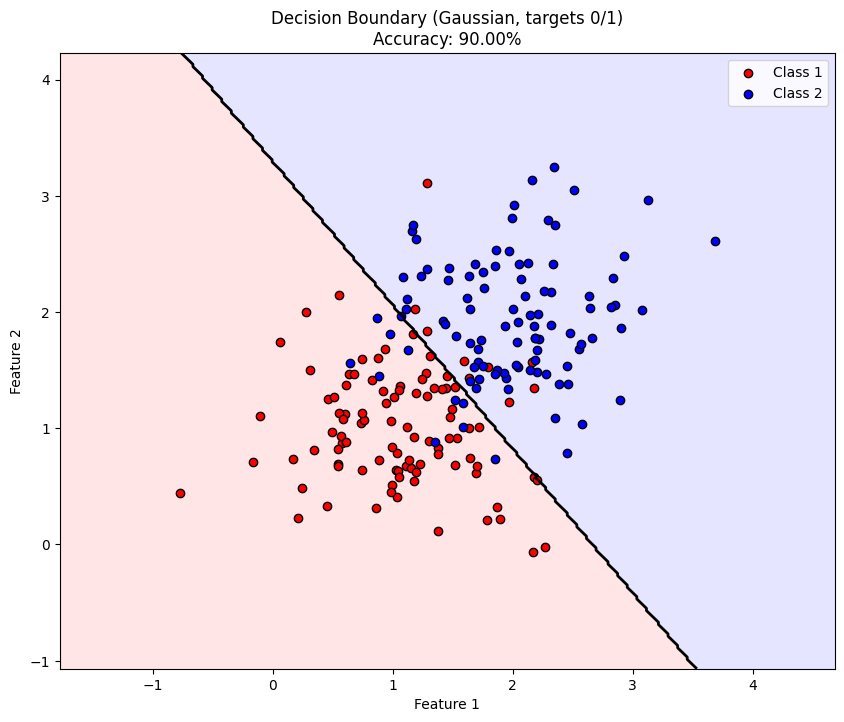


Part 1-e: Gaussian data with targets -1 and 1
Accuracy with target values -1 and 1: 90.00%


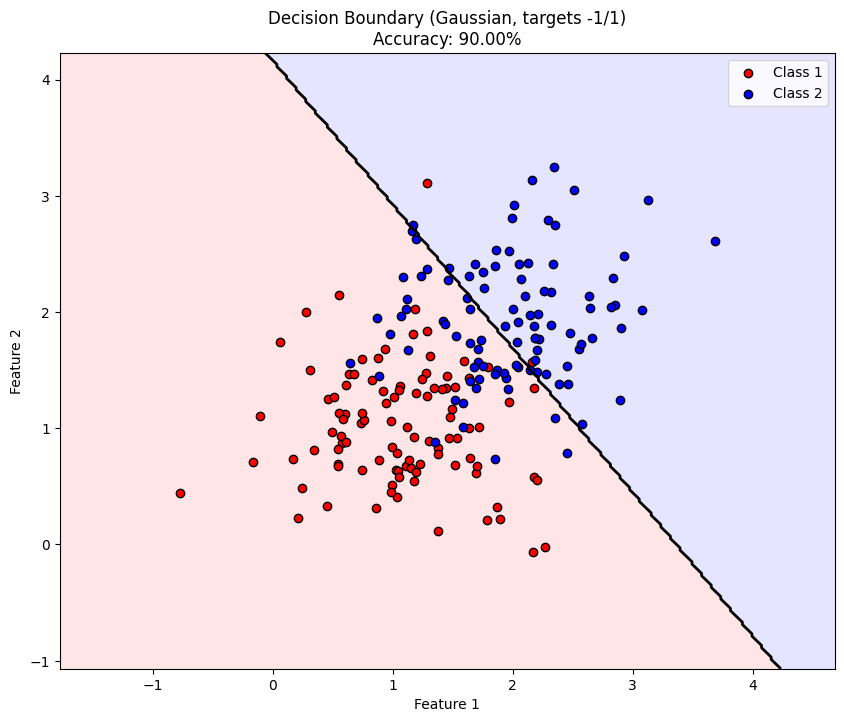


Part 1-f: Laplacian data with targets 0 and 1
Accuracy with Laplacian distribution: 80.50%


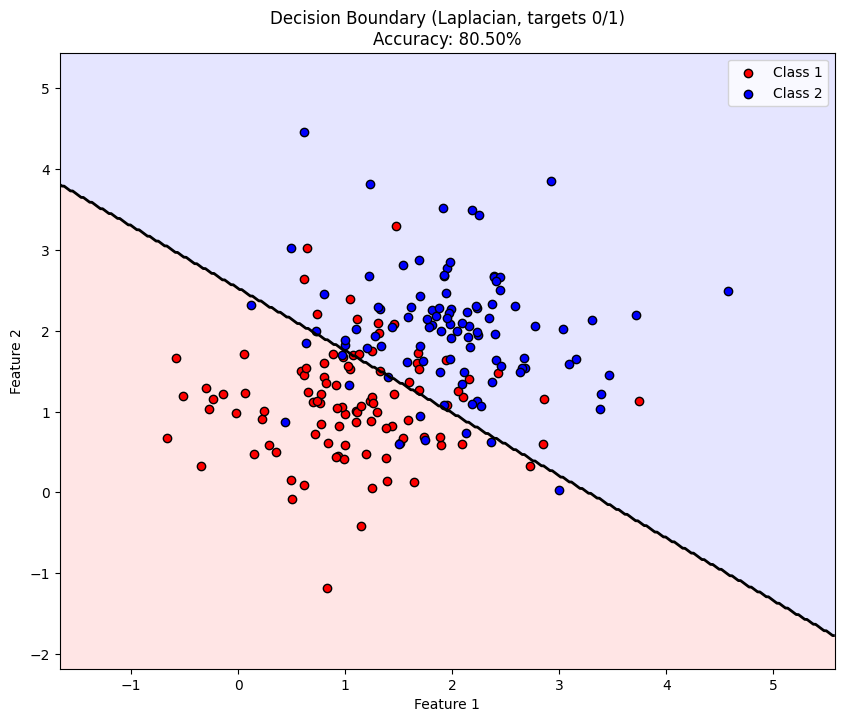


Part 1-f (continued): Laplacian data with targets -1 and 1
Accuracy with Laplacian distribution and targets -1/1: 80.50%


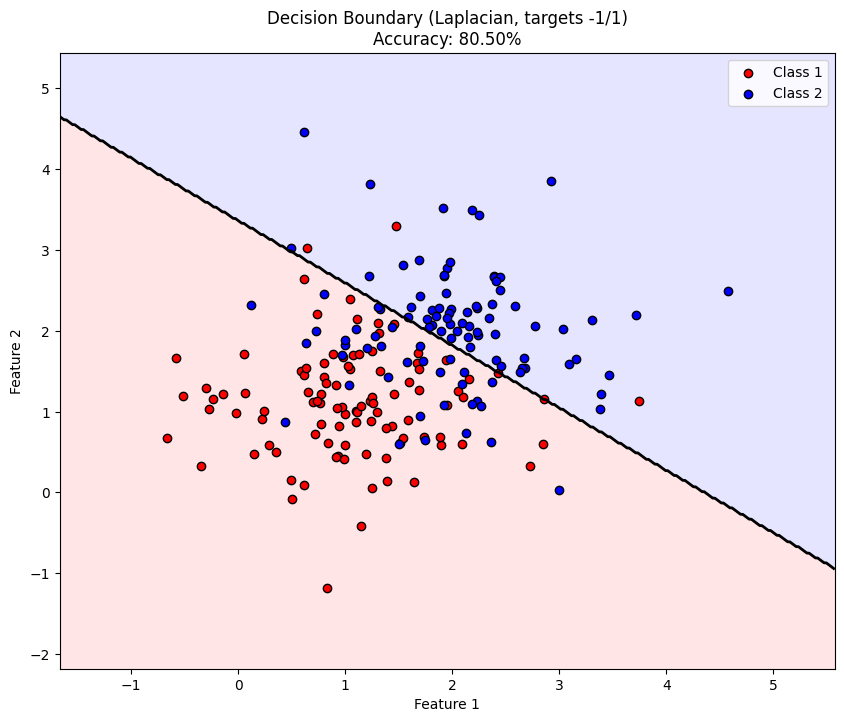


Part 1-g: Observations
1. Gaussian vs Laplacian distributions: 
   - Gaussian accuracy with 0/1 targets: 90.00%
   - Laplacian accuracy with 0/1 targets: 80.50%
2. Target value notation impact:
   - Gaussian with 0/1 targets: 90.00%
   - Gaussian with -1/1 targets: 90.00%
   - Laplacian with 0/1 targets: 80.50%
   - Laplacian with -1/1 targets: 80.50%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random
import math

########################################
#Part-1)-a: Data generation
########################################

def generate_gaussian_data(mean1, mean2, cov, n_train, n_test):
    """Generate Gaussian data for two classes"""
    # Set the parameters of class distribution
    # Generate training data
    class1_tr = np.random.multivariate_normal(mean1, cov, n_train)
    class2_tr = np.random.multivariate_normal(mean2, cov, n_train)
    tr_data = np.vstack((class1_tr, class2_tr))

    # Generate testing data
    class1_te = np.random.multivariate_normal(mean1, cov, n_test)
    class2_te = np.random.multivariate_normal(mean2, cov, n_test)
    te_data = np.vstack((class1_te, class2_te))

    return class1_tr, class2_tr, tr_data, class1_te, class2_te, te_data

def generate_laplacian_data(loc1, loc2, scale, n_train, n_test, dim=2):
    """Generate Laplacian data for two classes"""
    # For each dimension, generate Laplacian distributed values
    class1_tr = np.array([np.random.laplace(loc1[i], scale, n_train) for i in range(dim)]).T
    class2_tr = np.array([np.random.laplace(loc2[i], scale, n_train) for i in range(dim)]).T
    tr_data = np.vstack((class1_tr, class2_tr))

    # Generate testing data
    class1_te = np.array([np.random.laplace(loc1[i], scale, n_test) for i in range(dim)]).T
    class2_te = np.array([np.random.laplace(loc2[i], scale, n_test) for i in range(dim)]).T
    te_data = np.vstack((class1_te, class2_te))

    return class1_tr, class2_tr, tr_data, class1_te, class2_te, te_data

########################################
#Part-1)-b: Find the decision boundary
########################################
def LS_Classify(X_train, Y_train, X_test):
    """
    Implement pseudo inverse solution to get the weight vector
    Inputs: Training data, Training labels, and Testing data
    Outputs: Testing labels
    """
    # Add a column of ones to X_train for the bias term
    X_train_bias = np.hstack((np.ones((X_train.shape[0], 1)), X_train))

    # Calculate pseudo inverse solution
    w = np.linalg.pinv(X_train_bias) @ Y_train

    # Add a column of ones to X_test for the bias term
    X_test_bias = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    # Predict the labels of test data
    Y_pred_raw = X_test_bias @ w

    # Convert to binary predictions (0 or 1)
    Y_pred = np.where(Y_pred_raw > 0.5, 1, 0)

    return Y_pred, w

def LS_Classify_with_threshold(X_train, Y_train, X_test, threshold=0.5):
    """Similar to LS_Classify but with adjustable threshold"""
    X_train_bias = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
    w = np.linalg.pinv(X_train_bias) @ Y_train

    X_test_bias = np.hstack((np.ones((X_test.shape[0], 1)), X_test))
    Y_pred_raw = X_test_bias @ w

    Y_pred = np.where(Y_pred_raw > threshold, 1, 0)

    return Y_pred, w

##########################################
#Part-1)-c: Evaluate the quality of decision boundary
##########################################
def LS_Classify_Accuracy(Y_test, Y_pred):
    """
    Compute the accuracy
    Inputs: Ground truth test labels and predicted test labels
    Outputs: Accuracy
    """
    # Count the number of correct predictions
    correct = np.sum(Y_test == Y_pred)

    # Calculate accuracy
    accuracy = correct / len(Y_test)

    return accuracy

##########################################
#Part-1)-d: Visualize the decision boundary
##########################################
def plot_decision_boundary(X, y, w, title="Decision Boundary"):
    """Plot the decision boundary and the data points"""
    # Create a meshgrid
    h = 0.02  # Step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Calculate the decision function value for each point in the meshgrid
    Z = w[0] + w[1] * xx + w[2] * yy
    Z = np.where(Z > 0.5, 1, 0)  # Threshold at 0.5

    # Plot the contour
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))

    # Plot the data points
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', edgecolors='k', label='Class 1')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', edgecolors='k', label='Class 2')

    # Add contour line for the decision boundary
    plt.contour(xx, yy, Z, [0.5], linewidths=2, colors='k')

    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()

# Set random seed for reproducibility
np.random.seed(42)

# Parameters for data generation
mean1 = [1, 1]
mean2 = [2, 2]
cov = [[0.3, 0], [0, 0.3]]
n_train = 50  # 50 samples per class for training
n_test = 100  # 100 samples per class for testing (200 total)

#################################
# Part-1)-a,b,c,d: Gaussian data with targets 0 and 1
#################################
print("Part 1-a,b,c,d: Gaussian data with targets 0 and 1")

# Generate Gaussian data
class1_tr, class2_tr, tr_data, class1_te, class2_te, te_data = generate_gaussian_data(mean1, mean2, cov, n_train, n_test)

# Create target labels: 0 for class 1, 1 for class 2
tr_targets = np.hstack((np.zeros(n_train), np.ones(n_train)))
te_targets = np.hstack((np.zeros(n_test), np.ones(n_test)))

# Get the test data predictions
predictions, weight_vector = LS_Classify(tr_data, tr_targets, te_data)

# Calculate accuracy
accuracy = LS_Classify_Accuracy(te_targets, predictions)
print(f"Accuracy with target values 0 and 1: {accuracy * 100:.2f}%")

# Visualize the decision boundary
plot_decision_boundary(te_data, te_targets, weight_vector,
                      title=f"Decision Boundary (Gaussian, targets 0/1)\nAccuracy: {accuracy * 100:.2f}%")

#################################
# Part-1)-e: Gaussian data with targets -1 and 1
#################################
print("\nPart 1-e: Gaussian data with targets -1 and 1")

# Create target labels: -1 for class 1, 1 for class 2
tr_targets_pm = np.hstack((np.full(n_train, -1), np.full(n_train, 1)))
te_targets_pm = np.hstack((np.full(n_test, -1), np.full(n_test, 1)))

# Get the test data predictions with adjusted threshold (0 instead of 0.5)
predictions_pm, weight_vector_pm = LS_Classify_with_threshold(tr_data, tr_targets_pm, te_data, threshold=0)

# Convert predictions back to -1 and 1 for accuracy calculation
predictions_pm_adjusted = np.where(predictions_pm == 0, -1, 1)

# Calculate accuracy
accuracy_pm = LS_Classify_Accuracy(te_targets_pm, predictions_pm_adjusted)
print(f"Accuracy with target values -1 and 1: {accuracy_pm * 100:.2f}%")

# Visualize the decision boundary
plot_decision_boundary(te_data, (te_targets_pm + 1) / 2, weight_vector_pm,  # Convert -1/1 to 0/1 for visualization
                      title=f"Decision Boundary (Gaussian, targets -1/1)\nAccuracy: {accuracy_pm * 100:.2f}%")

#################################
# Part-1)-f: Laplacian data with targets 0 and 1
#################################
print("\nPart 1-f: Laplacian data with targets 0 and 1")

# Generate Laplacian data
loc1 = mean1  # Use the same means as Gaussian
loc2 = mean2
scale = 0.5   # Scale parameter for Laplacian

class1_tr_lap, class2_tr_lap, tr_data_lap, class1_te_lap, class2_te_lap, te_data_lap = generate_laplacian_data(
    loc1, loc2, scale, n_train, n_test)

# Create target labels: 0 for class 1, 1 for class 2
tr_targets_lap = np.hstack((np.zeros(n_train), np.ones(n_train)))
te_targets_lap = np.hstack((np.zeros(n_test), np.ones(n_test)))

# Get the test data predictions
predictions_lap, weight_vector_lap = LS_Classify(tr_data_lap, tr_targets_lap, te_data_lap)

# Calculate accuracy
accuracy_lap = LS_Classify_Accuracy(te_targets_lap, predictions_lap)
print(f"Accuracy with Laplacian distribution: {accuracy_lap * 100:.2f}%")

# Visualize the decision boundary
plot_decision_boundary(te_data_lap, te_targets_lap, weight_vector_lap,
                      title=f"Decision Boundary (Laplacian, targets 0/1)\nAccuracy: {accuracy_lap * 100:.2f}%")

# Try Laplacian with -1 and 1 targets
print("\nPart 1-f (continued): Laplacian data with targets -1 and 1")

# Create target labels: -1 for class 1, 1 for class 2
tr_targets_lap_pm = np.hstack((np.full(n_train, -1), np.full(n_train, 1)))
te_targets_lap_pm = np.hstack((np.full(n_test, -1), np.full(n_test, 1)))

# Get the test data predictions with adjusted threshold
predictions_lap_pm, weight_vector_lap_pm = LS_Classify_with_threshold(tr_data_lap, tr_targets_lap_pm, te_data_lap, threshold=0)

# Convert predictions back to -1 and 1 for accuracy calculation
predictions_lap_pm_adjusted = np.where(predictions_lap_pm == 0, -1, 1)

# Calculate accuracy
accuracy_lap_pm = LS_Classify_Accuracy(te_targets_lap_pm, predictions_lap_pm_adjusted)
print(f"Accuracy with Laplacian distribution and targets -1/1: {accuracy_lap_pm * 100:.2f}%")

# Visualize the decision boundary
plot_decision_boundary(te_data_lap, (te_targets_lap_pm + 1) / 2, weight_vector_lap_pm,
                      title=f"Decision Boundary (Laplacian, targets -1/1)\nAccuracy: {accuracy_lap_pm * 100:.2f}%")

#################################
# Part-1)-g: Observations
#################################
print("\nPart 1-g: Observations")
print("1. Gaussian vs Laplacian distributions: ")
print(f"   - Gaussian accuracy with 0/1 targets: {accuracy * 100:.2f}%")
print(f"   - Laplacian accuracy with 0/1 targets: {accuracy_lap * 100:.2f}%")
print("2. Target value notation impact:")
print(f"   - Gaussian with 0/1 targets: {accuracy * 100:.2f}%")
print(f"   - Gaussian with -1/1 targets: {accuracy_pm * 100:.2f}%")
print(f"   - Laplacian with 0/1 targets: {accuracy_lap * 100:.2f}%")
print(f"   - Laplacian with -1/1 targets: {accuracy_lap_pm * 100:.2f}%")

<b>Report your observations</b>

1.Gaussian-distributed data achieves high classification accuracy, with the pseudo-inverse solution forming a clear and effective decision boundary that separates the classes well.

2.Changing the label encoding from (0,1) to (-1,+1) still yields good results using the same least squares framework, indicating label encoding flexibility with linear models.

3.Laplacian-distributed data leads to slightly lower accuracy, possibly due to heavier tails and more variance in the data, showing how distributional assumptions can impact performance.



<b> Part - (2) :  Linear & Fisher Discriminant analysis : </b> In this segment of the programming task, you'll learn the technique of projecting data from higher-dimensional to lower-dimensional space using both Linear Discriminant Analysis and Fisher Discriminant Analysis.

a). Data generation: Consider a classification scenario with two classes. Class 1 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 1  \\ 1  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Class 2 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 2  \\ 2  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Employ these class distributions to generate 50 samples per class for training and 200 samples for testing.

b). Projection using only the between-class covariance: Develop a function for performing projection from 2-D space to 1-D utilizing Linear Discriminant Analysis. It's important to emphasize that this method only considers the between-class covariance. Project the previously generated 2-D synthetic data into 1-D and conduct classification. Plot both the original and projected data points on the same graph.

c). Projection utilizing both between-class and within-class covariance: Create a function to perform projection from 2-D space to 1-D using Fisher Discriminant Analysis. It's essential to mention that this method considers both between-class covariance and within-class covariance. Project the previously generated 2-D synthetic data into 1-D and conduct classification. Plot both the original and projected data points on the same graph.

d). Extend Fisher discriminant analysis function to project the data from N dimenision to K dimension.

e). Report your observations.


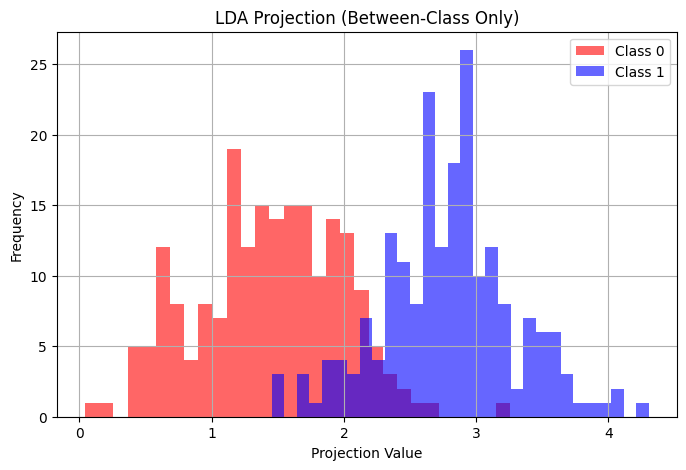

Accuracy with LDA: 90.5


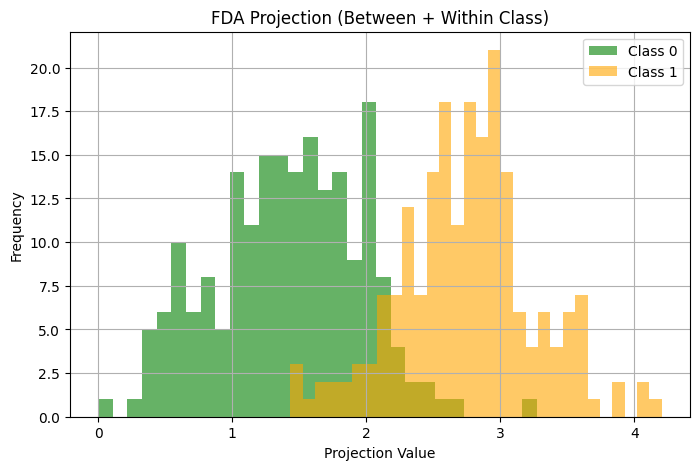

Accuracy with FDA: 91.0


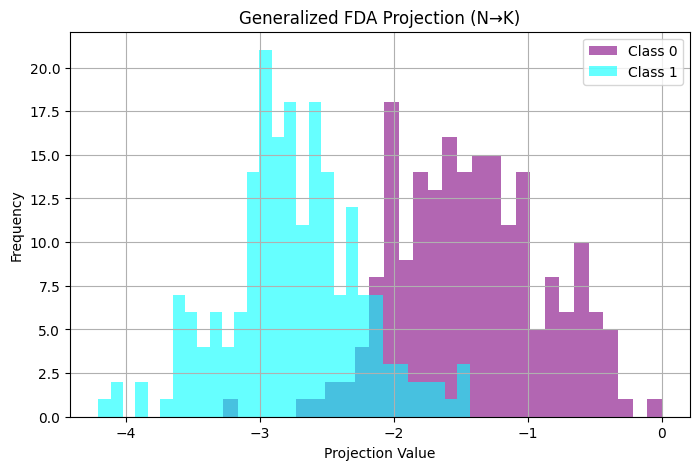

In [ ]:
#All imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random
import math

########################################
#Part-2)-(a): Data generation
########################################

#Set the parameters of class distribution
mean1 = [1,1]
mean2 = [2,2]
cov = [[0.3,0],[0,0.3]]

#Generate training data
class1_tr = np.random.multivariate_normal(mean1, cov, 50)
class2_tr = np.random.multivariate_normal(mean2, cov, 50)
tr_data = np.vstack((class1_tr, class2_tr))
tr_targets = np.hstack((np.zeros(50), np.ones(50)))

#Generate testing data
class1_te = np.random.multivariate_normal(mean1, cov, 200)
class2_te = np.random.multivariate_normal(mean2, cov, 200)
te_data = np.vstack((class1_te, class2_te))
te_targets = np.hstack((np.zeros(200), np.ones(200)))

########################################
#Part-2)-(b): LDA using between-class covariance
########################################
def LDA_classify(X_train, Y_train, X_test):
    mean1 = np.mean(X_train[Y_train == 0], axis=0)
    mean2 = np.mean(X_train[Y_train == 1], axis=0)

    w = mean2 - mean1
    w = w / np.linalg.norm(w)  # Normalize

    # Project training data
    proj1 = np.dot(mean1, w)
    proj2 = np.dot(mean2, w)
    threshold = (proj1 + proj2) / 2

    projections = np.dot(X_test, w)
    predictions = (projections > threshold).astype(int)
    return predictions, w

predictions_lda, w_lda = LDA_classify(tr_data, tr_targets, te_data)

def LDA_project(w, X_test, Y_test):
    projections = np.dot(X_test, w)
    plt.figure(figsize=(8,5))
    plt.hist(projections[Y_test == 0], bins=30, alpha=0.6, label='Class 0', color='red')
    plt.hist(projections[Y_test == 1], bins=30, alpha=0.6, label='Class 1', color='blue')
    plt.title("LDA Projection (Between-Class Only)")
    plt.xlabel("Projection Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()

LDA_project(w_lda, te_data, te_targets)

acc = np.mean(predictions_lda == te_targets)
print('Accuracy with LDA:', acc*100)

########################################
#Part-2)-(c): FDA using between and within-class covariance
########################################
def FDA_classify(X_train, Y_train, X_test):
    X1 = X_train[Y_train == 0]
    X2 = X_train[Y_train == 1]
    mean1 = np.mean(X1, axis=0)
    mean2 = np.mean(X2, axis=0)

    Sw = np.cov(X1, rowvar=False) + np.cov(X2, rowvar=False)
    w = np.linalg.pinv(Sw) @ (mean2 - mean1)
    w = w / np.linalg.norm(w)

    proj1 = np.dot(mean1, w)
    proj2 = np.dot(mean2, w)
    threshold = (proj1 + proj2) / 2

    projections = np.dot(X_test, w)
    predictions = (projections > threshold).astype(int)
    return w, predictions

w_fda, predictions_fda = FDA_classify(tr_data, tr_targets, te_data)

def FDA_project(w, X_test, Y_test):
    projections = np.dot(X_test, w)
    plt.figure(figsize=(8,5))
    plt.hist(projections[Y_test == 0], bins=30, alpha=0.6, label='Class 0', color='green')
    plt.hist(projections[Y_test == 1], bins=30, alpha=0.6, label='Class 1', color='orange')
    plt.title("FDA Projection (Between + Within Class)")
    plt.xlabel("Projection Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()

FDA_project(w_fda, te_data, te_targets)

acc = np.mean(predictions_fda == te_targets)
print('Accuracy with FDA:', acc*100)

########################################
#Part-2)-(d): Generalized FDA to N→K dimension
########################################
def FDA_project_K(X_train, Y_train, X_test, k):
    classes = np.unique(Y_train)
    means = []
    Sw = np.zeros((X_train.shape[1], X_train.shape[1]))
    Sb = np.zeros((X_train.shape[1], X_train.shape[1]))
    overall_mean = np.mean(X_train, axis=0)

    for c in classes:
        Xc = X_train[Y_train == c]
        mean_c = np.mean(Xc, axis=0)
        means.append(mean_c)
        Sw += np.cov(Xc, rowvar=False) * (Xc.shape[0] - 1)
        n_c = Xc.shape[0]
        mean_diff = (mean_c - overall_mean).reshape(-1,1)
        Sb += n_c * (mean_diff @ mean_diff.T)

    eig_vals, eig_vecs = np.linalg.eig(np.linalg.pinv(Sw) @ Sb)
    idx = np.argsort(-np.abs(eig_vals))
    W = eig_vecs[:, idx[:k]]
    return W

# Example usage for projecting 2D to 1D
W_fda_k = FDA_project_K(tr_data, tr_targets, te_data, k=1)
projected_test_k = te_data @ W_fda_k
plt.figure(figsize=(8,5))
plt.hist(projected_test_k[te_targets == 0], bins=30, alpha=0.6, label='Class 0', color='purple')
plt.hist(projected_test_k[te_targets == 1], bins=30, alpha=0.6, label='Class 1', color='cyan')
plt.title("Generalized FDA Projection (N→K)")
plt.xlabel("Projection Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


<b>Report your observations</b>

1.LDA considers only the difference in class means, which works well for clearly separated classes but may be less robust when there's significant within-class variation.

2.FDA performs better by accounting for both between-class and within-class variances, leading to more compact and better-separated projections for classification.

3.Generalizing FDA to N→K dimensions using eigen decomposition allows us to handle multi-class and high-dimensional problems efficiently by choosing the top K discriminative components.

<b> Part (3) : Classification using perceptron algorithm </b>

a). Data generation: Consider a classification scenario with two classes. Class 1 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 1  \\ 1  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Class 2 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 2  \\ 2  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Employ these class distributions to generate 50 samples per class for training and 200 samples for testing.


b). Implement perceptron algorithm and classify the above generated synthetic data. Plot the decision boundary/regions.

c). Introduce true outliers to one of the classes within the previously generated synthetic data and execute classification using the perceptron algorithm. Illustrate the decision boundary/regions. Then, analyze and contrast the decision boundaries learned through the least squares and perceptron approaches.

d). Let us consider four Gaussian distributions with mean vectors as $\begin{bmatrix} 0  \\ 0  \end{bmatrix}$, $\begin{bmatrix} 0  \\ 1  \end{bmatrix}$, $\begin{bmatrix} 1  \\ 1  \end{bmatrix}$, and $\begin{bmatrix} 1  \\ 0  \end{bmatrix}$, respectively. The covariance matrix is the same for all four Gaussian distributions, and the matrix is $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Sample 60 data points from each distribution to get 240 data points. Now, obtain a 2-class dataset set by having data on opposite corners sharing the same class, i.e., data points sampled from Gaussian distributions with mean vectors $\begin{bmatrix} 0  \\ 0  \end{bmatrix}$ and $\begin{bmatrix} 1  \\ 1  \end{bmatrix}$ belong to class 1, and the data points sampled from the other two distributions belong to class 2. Assign class 1 data points with the label +1 and class 2 with the label -1. Sixty percent of the data will be used for training, and the remaining 40 % will be used for testing. You can see that it represents the XOR problem. Classify this data set using the perceptron algorithm.
  

e). Report your observations


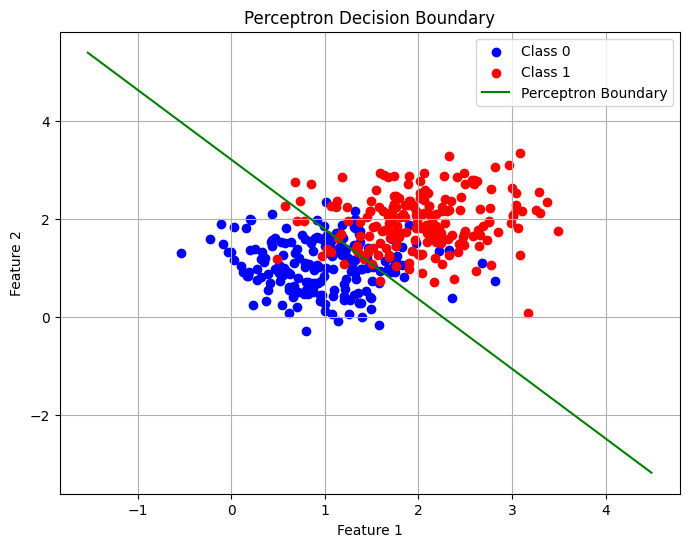

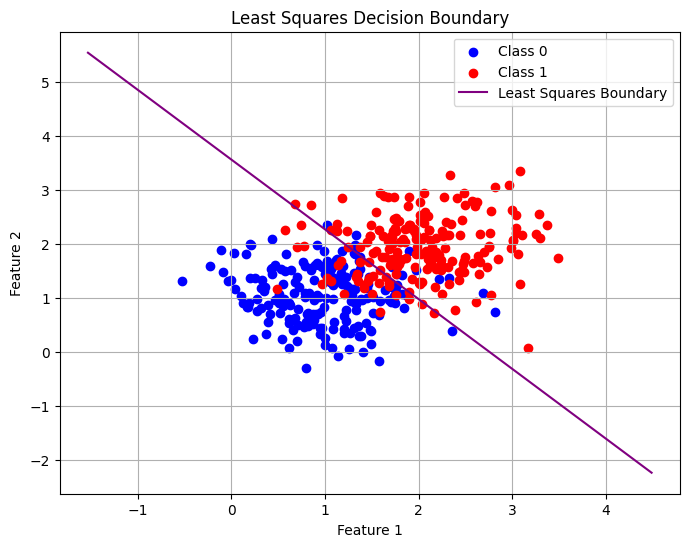

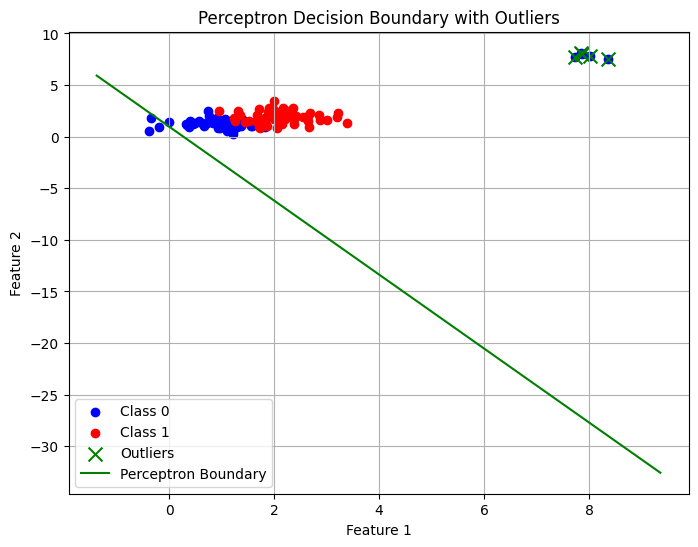

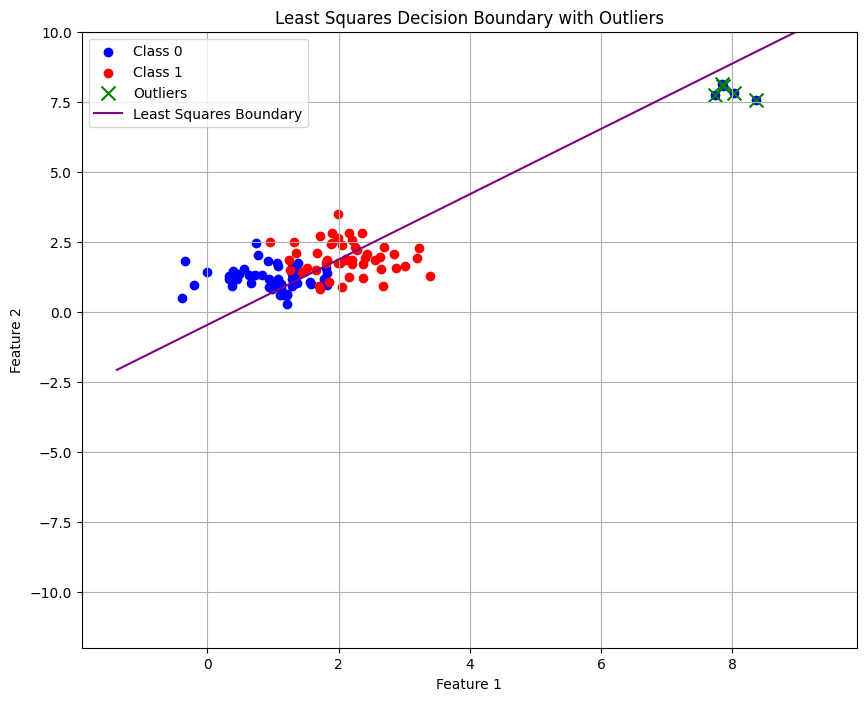

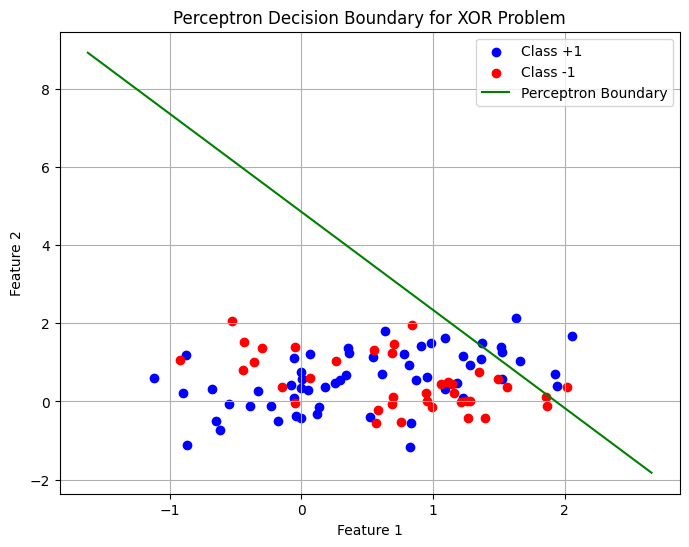

Accuracy on XOR problem: 46.88%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random
import math

########################################
#Part-3)-(a): Data generation
########################################

#Set the parameters of class distribution
mean1 = [1,1]           #Mean of class1
mean2 = [2,2]           #Mean of class2
cov = [[0.3,0],[0,0.3]] #Covariance matrix. Same covariance for class1 and class2

#Generate training data
class1_tr = np.random.multivariate_normal(mean1, cov, 50)  #Class1 training data
class2_tr = np.random.multivariate_normal(mean2, cov, 50)  #Class2 training data
tr_data = np.vstack((class1_tr, class2_tr))                #Combine class1 and class2 training data
tr_targets = np.hstack((np.zeros(50), np.ones(50)))        #Class labels: 0 for class1, 1 for class2

#Generate testing data
class1_te = np.random.multivariate_normal(mean1, cov, 200) #Class1 testing data
class2_te = np.random.multivariate_normal(mean2, cov, 200) #Class2 testing data
te_data = np.vstack((class1_te, class2_te))                #Combine class1 and class2 testing data
te_targets = np.hstack((np.zeros(200), np.ones(200)))      #Class labels: 0 for class1, 1 for class2

########################################
#Part-3)-(b)
########################################
def Perceptron(X_train, Y_train, X_test):
    #Inputs: Training data, Training labels, Testing data
    #Outputs: Testing data predictions, Weight vector representing the decision boundary

    epochs = 100  #Number of epochs
    X = np.c_[np.ones(X_train.shape[0]), X_train]  #Data. Append ones to the training data to take care of the bias
    w = np.zeros(X.shape[1])  #Initialize the weight vector

    # Convert targets to {-1, 1} for perceptron algorithm
    Y = 2*Y_train - 1

    for epoch in range(epochs):
        for i in range(X.shape[0]):
            # Update weights only if misclassified
            if (np.dot(X[i], w) * Y[i]) <= 0:
                w = w + Y[i] * X[i]

    #Compute the test data predictions using the final weight vector
    X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]
    predictions = np.sign(np.dot(X_test_bias, w))

    # Convert predictions back to {0, 1}
    predictions = (predictions + 1) / 2

    #Return the test data predictions and the final weight vector
    return predictions, w

# Run perceptron algorithm on training data
predictions, weights = Perceptron(tr_data, tr_targets, te_data)

##########################################
#Plot the decision boundary using perceptron
##########################################
plt.figure(figsize=(8, 6))
plt.scatter(te_data[te_targets==0][:,0], te_data[te_targets==0][:,1], color='blue', label='Class 0')
plt.scatter(te_data[te_targets==1][:,0], te_data[te_targets==1][:,1], color='red', label='Class 1')

# Plot decision boundary
x_vals = np.linspace(te_data[:,0].min() - 1, te_data[:,0].max() + 1, 100)
y_vals = -(weights[1]/weights[2])*x_vals - (weights[0]/weights[2])
plt.plot(x_vals, y_vals, label='Perceptron Boundary', color='green')

plt.title("Perceptron Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

##########################################
#Plot the decision boundary using least squares
##########################################
# Implement least squares solution
X_ls = np.c_[np.ones(tr_data.shape[0]), tr_data]
y_ls = 2*tr_targets - 1  # Convert to {-1, 1}
w_ls = np.linalg.pinv(X_ls) @ y_ls

plt.figure(figsize=(8, 6))
plt.scatter(te_data[te_targets==0][:,0], te_data[te_targets==0][:,1], color='blue', label='Class 0')
plt.scatter(te_data[te_targets==1][:,0], te_data[te_targets==1][:,1], color='red', label='Class 1')

# Plot decision boundary
x_vals = np.linspace(te_data[:,0].min() - 1, te_data[:,0].max() + 1, 100)
y_vals = -(w_ls[1]/w_ls[2])*x_vals - (w_ls[0]/w_ls[2])
plt.plot(x_vals, y_vals, label='Least Squares Boundary', color='purple')

plt.title("Least Squares Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

##########################################
#Part-3)-(c): Repeat the experiments with the true outliers added to the data. Compare and contrast the perceptron algorithm with least squares method
##########################################
# Add outliers to class 1
outliers = np.random.multivariate_normal([8, 8], [[0.1, 0], [0, 0.1]], 5)
class1_tr_outliers = np.vstack((class1_tr, outliers))
tr_data_outliers = np.vstack((class1_tr_outliers, class2_tr))
tr_targets_outliers = np.hstack((np.zeros(55), np.ones(50)))

# Run perceptron with outliers
predictions_outliers, weights_outliers = Perceptron(tr_data_outliers, tr_targets_outliers, te_data)

# Run least squares with outliers
X_ls_outliers = np.c_[np.ones(tr_data_outliers.shape[0]), tr_data_outliers]
y_ls_outliers = 2*tr_targets_outliers - 1
w_ls_outliers = np.linalg.pinv(X_ls_outliers) @ y_ls_outliers

# Plot perceptron with outliers
plt.figure(figsize=(8, 6))
plt.scatter(tr_data_outliers[tr_targets_outliers==0][:,0], tr_data_outliers[tr_targets_outliers==0][:,1],
            color='blue', label='Class 0')
plt.scatter(tr_data_outliers[tr_targets_outliers==1][:,0], tr_data_outliers[tr_targets_outliers==1][:,1],
            color='red', label='Class 1')
plt.scatter(outliers[:,0], outliers[:,1], color='green', marker='x', s=100, label='Outliers')

x_vals = np.linspace(tr_data_outliers[:,0].min() - 1, tr_data_outliers[:,0].max() + 1, 100)
y_vals = -(weights_outliers[1]/weights_outliers[2])*x_vals - (weights_outliers[0]/weights_outliers[2])
plt.plot(x_vals, y_vals, label='Perceptron Boundary', color='green')

plt.title("Perceptron Decision Boundary with Outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

# Plot least squares with outliers
plt.figure(figsize=(10, 8))
plt.scatter(tr_data_outliers[tr_targets_outliers==0][:,0], tr_data_outliers[tr_targets_outliers==0][:,1],
            color='blue', label='Class 0')
plt.scatter(tr_data_outliers[tr_targets_outliers==1][:,0], tr_data_outliers[tr_targets_outliers==1][:,1],
            color='red', label='Class 1')
plt.scatter(outliers[:,0], outliers[:,1], color='green', marker='x', s=100, label='Outliers')

x_vals = np.linspace(tr_data_outliers[:,0].min() - 1, tr_data_outliers[:,0].max() + 1, 100)
y_vals = -(w_ls_outliers[1]/w_ls_outliers[2])*x_vals - (w_ls_outliers[0]/w_ls_outliers[2])
plt.plot(x_vals, y_vals, label='Least Squares Boundary', color='purple')

plt.title("Least Squares Decision Boundary with Outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.ylim(-12, 10)  # Adjust y-axis to see the boundary
plt.show()

##########################################
#Part-3)-(d): Data generation XOR
##########################################

#Set the parameters of Gaussian distribution
class1_mean1 = [0, 0]  #Mean of Gaussian1
class1_mean2 = [1, 1]  #Mean of Gaussian3
class2_mean1 = [0, 1]  #Mean of Gaussian2
class2_mean2 = [1, 0]  #Mean of Gaussian4
cov = [[0.3, 0], [0, 0.3]]  #Covariance matrix. Same covariance for all distributions

#Generate data
class1_data1 = np.random.multivariate_normal(class1_mean1, cov, 60)
class1_data2 = np.random.multivariate_normal(class1_mean2, cov, 60)
class2_data1 = np.random.multivariate_normal(class2_mean1, cov, 60)
class2_data2 = np.random.multivariate_normal(class2_mean2, cov, 60)

#Obtain 2-class dataset
class1_data = np.vstack((class1_data1, class1_data2))
class2_data = np.vstack((class2_data1, class2_data2))
data = np.vstack((class1_data, class2_data))
targets = np.hstack((np.ones(120), -np.ones(120)))

#Create train test splits
indices = np.random.permutation(data.shape[0])
train_size = int(0.6 * data.shape[0])
train_idx, test_idx = indices[:train_size], indices[train_size:]
X_train, X_test = data[train_idx], data[test_idx]
Y_train, Y_test = targets[train_idx], targets[test_idx]

#Classify this dataset using perceptron algorithm
perceptron_preds_xor, w_perceptron_xor = Perceptron(X_train, (Y_train + 1)/2, X_test)  # Convert to {0,1} for our function

#Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.scatter(X_test[Y_test==1][:,0], X_test[Y_test==1][:,1], color='blue', label='Class +1')
plt.scatter(X_test[Y_test==-1][:,0], X_test[Y_test==-1][:,1], color='red', label='Class -1')

# Plot decision boundary
x_vals = np.linspace(data[:,0].min() - 0.5, data[:,0].max() + 0.5, 100)
y_vals = -(w_perceptron_xor[1]/w_perceptron_xor[2])*x_vals - (w_perceptron_xor[0]/w_perceptron_xor[2])
plt.plot(x_vals, y_vals, label='Perceptron Boundary', color='green')

plt.title("Perceptron Decision Boundary for XOR Problem")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

# Calculate accuracy
accuracy = np.mean((2*perceptron_preds_xor - 1) == Y_test) * 100
print(f"Accuracy on XOR problem: {accuracy:.2f}%")


<b> Report your observations </b>

1.The perceptron algorithm successfully separates linearly separable data (as in part b) with a clear decision boundary, but struggles with the XOR problem (part d) because it's not linearly separable, resulting in poor classification performance.

2.When outliers are introduced (part c), the perceptron algorithm is more robust compared to least squares, as perceptron focuses on finding a separating hyperplane rather than minimizing the squared error across all points.

3.The least squares method is more sensitive to outliers than the perceptron algorithm, as evidenced by the significant shift in its decision boundary when outliers are added, while perceptron maintains a more stable boundary focused on classification rather than regression.



<b> Part (4) : Understanding the decision boundaries of MAP approach to classification - </b> Decision boundary in 2 class classification problem is the locus of points satisfying $p(c_{1}/x)$ = $p(c_{2}/x)$. Where $c_{1}$ and $c_{2}$ are the class indicators and $x$ is the data. With proper assumpuptions on prior and likelihood, p(c/x) follows Gaussian distribution with appropriate parameters. Given the parameters of the Guassian distribution for the two classes i.e $\mu_{1},\Sigma_{1},\mu_{2},\Sigma_{2}$, we can derive the decision boundary equation i.e W and $w_{0}$. You may refer to class notes for the derivations and final equations. In this part of programming assignment we expect you to code the decision boundaries for the Gaussian distribution case and understand them.

**a). Class distributions share the same covariance matrix: Linear decision boundary.**
  0. Let $\mu_{1} = \begin{bmatrix} 1  \\ 1 \end{bmatrix}$, $\mu_{2} = \begin{bmatrix} 4  \\ 1 \end{bmatrix}$, and $\Sigma_{1}= \Sigma_{2} = \Sigma =  \begin{bmatrix} 0.1 & 0.0  \\ 0.0 & 0.1 \end{bmatrix}$
  1. Generate 100 samples from each class. This data set is used to understand the decision boundaries when $p(c_{1}) = p(c_{2})$
  2. Generate 50 samples from class1 and 150 samples from class2. This data set is used to understand the decision boundaries when $p(c_{1}) < p(c_{2})$
  3. Generate 150 samples from class1 and 50 samples from class2. This data set is used to understand the decision boundaries when $p(c_{1}) > p(c_{2})$
  4. Plot the decision boundaries for all the three cases in three different subplots.


**b). Class distributions have different covariance matrices: Non-linear decision boundary.**
  0. Let $\mu_{1} = \begin{bmatrix} 1  \\ 1 \end{bmatrix}$, $\mu_{2} = \begin{bmatrix} 3  \\ 1 \end{bmatrix}$, $\Sigma_{1}=   \begin{bmatrix} 0.2 & 0.0  \\ 0.0 & 0.02 \end{bmatrix}$, and $\Sigma_{2}=   \begin{bmatrix} 0.02 & 0.0  \\ 0.0 & 0.2 \end{bmatrix}$
  1. Generate 100 samples from each class. This data set is used to understand the decision boundaries when $p(c_{1}) = p(c_{2})$
  2. Generate 50 samples from class1 and 150 samples from class2. This data set is used to understand the decision boundaries when $p(c_{1}) < p(c_{2})$
  3. Generate 150 samples from class1 and 50 samples from class2. This data set is used to understand the decision boundaries when $p(c_{1}) > p(c_{2})$
  4. Plot the decision boundaries for all the three cases in three different subplots.


**c). Report your observations**




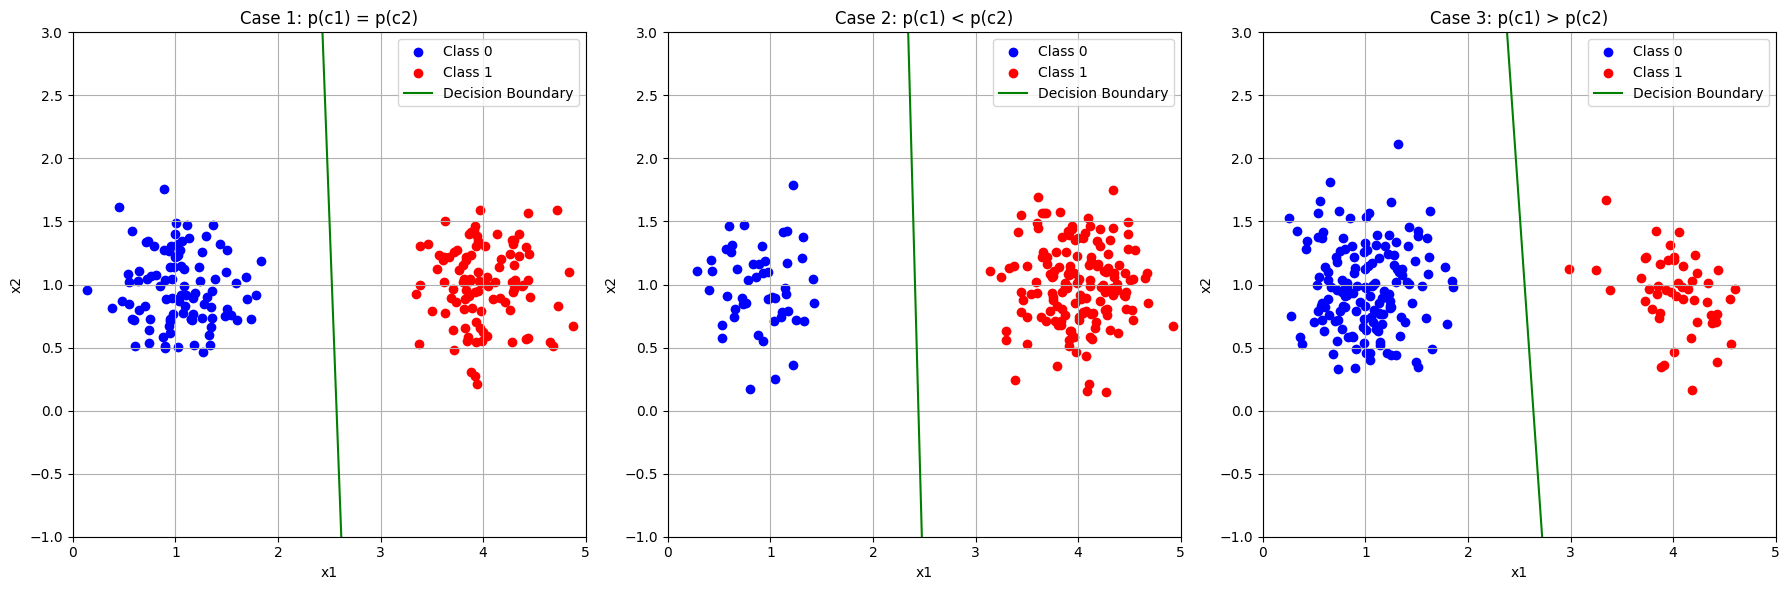

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random
import math

##########################################
#Part-4a)-0: Data Generation
##########################################
m1 = np.array([1, 1])  # Mean of class 1
m2 = np.array([4, 1])  # Mean of class 2
cov = np.array([[0.1, 0], [0, 0.1]])  # Shared covariance matrix

#Case1: Generate 100 samples from each class
class1_case1 = np.random.multivariate_normal(m1, cov, 100)
class2_case1 = np.random.multivariate_normal(m2, cov, 100)
case1_data = np.vstack((class1_case1, class2_case1))
case1_labels = np.hstack((np.zeros(100), np.ones(100)))

#Case2: Generate 50 samples from class1 and 150 samples from class2
class1_case2 = np.random.multivariate_normal(m1, cov, 50)
class2_case2 = np.random.multivariate_normal(m2, cov, 150)
case2_data = np.vstack((class1_case2, class2_case2))
case2_labels = np.hstack((np.zeros(50), np.ones(150)))

#Case3: Generate 150 samples from class1 and 50 samples from class2
class1_case3 = np.random.multivariate_normal(m1, cov, 150)
class2_case3 = np.random.multivariate_normal(m2, cov, 50)
case3_data = np.vstack((class1_case3, class2_case3))
case3_labels = np.hstack((np.zeros(150), np.ones(50)))

##########################################
#Part-4a)-4: Plot the decision regions for all the three cases
##########################################
def decisionBoundary(X_train, Y_train):
    #Inputs: Training data and Training labels
    #Outputs: Decision boundary parameters, i.e., w0, w
    p_c1 = np.mean(Y_train == 0)
    p_c2 = 1. - p_c1

    mean_1 = np.mean(X_train[Y_train == 0], axis=0)
    mean_2 = np.mean(X_train[Y_train == 1], axis=0)

    # Since covariance is shared, estimate from all data
    cov1 = np.cov(X_train[Y_train == 0].T)
    cov2 = np.cov(X_train[Y_train == 1].T)

    # For equal covariance case, use weighted average
    n1 = np.sum(Y_train == 0)
    n2 = np.sum(Y_train == 1)
    cov = (n1 * cov1 + n2 * cov2) / (n1 + n2)

    # Calculate weight vector and bias
    w = np.linalg.inv(cov) @ (mean_1 - mean_2)
    w0 = -0.5 * mean_1.T @ np.linalg.inv(cov) @ mean_1 + 0.5 * mean_2.T @ np.linalg.inv(cov) @ mean_2 + np.log(p_c1 / p_c2)

    return np.array([w0] + list(w))

#Plot the decision regions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cases = [(case1_data, case1_labels, "Case 1: p(c1) = p(c2)"),
         (case2_data, case2_labels, "Case 2: p(c1) < p(c2)"),
         (case3_data, case3_labels, "Case 3: p(c1) > p(c2)")]

for i, (data, labels, title) in enumerate(cases):
    w = decisionBoundary(data, labels)

    # Plot the data points
    axes[i].scatter(data[labels == 0][:, 0], data[labels == 0][:, 1], color='blue', label='Class 0')
    axes[i].scatter(data[labels == 1][:, 0], data[labels == 1][:, 1], color='red', label='Class 1')

    # Plot the decision boundary
    x_vals = np.linspace(0, 5, 100)
    y_vals = -(w[1]/w[2])*x_vals - (w[0]/w[2])
    axes[i].plot(x_vals, y_vals, color='green', label='Decision Boundary')

    axes[i].set_title(title)
    axes[i].set_xlabel("x1")
    axes[i].set_ylabel("x2")
    axes[i].legend()
    axes[i].grid(True)
    axes[i].set_xlim(0, 5)
    axes[i].set_ylim(-1, 3)

plt.tight_layout()
plt.show()


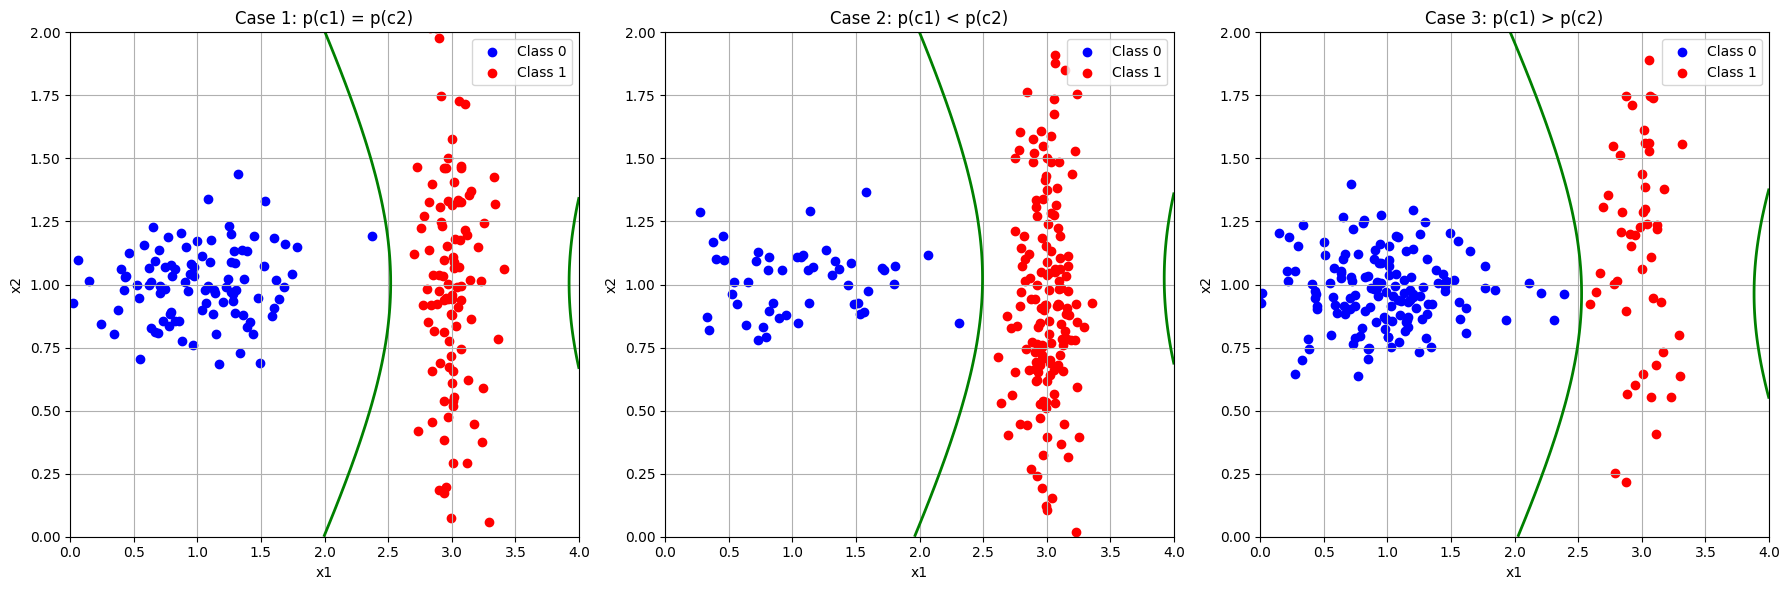

In [ ]:

##########################################
#Part-4b)-0: Data Generation
##########################################
m1 = np.array([1, 1])  # Mean of class 1
m2 = np.array([3, 1])  # Mean of class 2
cov1 = np.array([[0.2, 0], [0, 0.02]])  # Covariance matrix for class 1
cov2 = np.array([[0.02, 0], [0, 0.2]])  # Covariance matrix for class 2

#Case1: Generate 100 samples from each class
class1_case1_b = np.random.multivariate_normal(m1, cov1, 100)
class2_case1_b = np.random.multivariate_normal(m2, cov2, 100)
case1_data_b = np.vstack((class1_case1_b, class2_case1_b))
case1_labels_b = np.hstack((np.zeros(100), np.ones(100)))

#Case2: Generate 50 samples from class1 and 150 samples from class2
class1_case2_b = np.random.multivariate_normal(m1, cov1, 50)
class2_case2_b = np.random.multivariate_normal(m2, cov2, 150)
case2_data_b = np.vstack((class1_case2_b, class2_case2_b))
case2_labels_b = np.hstack((np.zeros(50), np.ones(150)))

#Case3: Generate 150 samples from class1 and 50 samples from class2
class1_case3_b = np.random.multivariate_normal(m1, cov1, 150)
class2_case3_b = np.random.multivariate_normal(m2, cov2, 50)
case3_data_b = np.vstack((class1_case3_b, class2_case3_b))
case3_labels_b = np.hstack((np.zeros(150), np.ones(50)))

##########################################
#Part-4b)-4: Plot the decision regions for all the three cases
##########################################
def decisionBoundaryNonLinear(X_train, Y_train, cov1, cov2):
    # Inputs: Training data, Training labels, Covariance matrices
    # Outputs: Function to evaluate the decision boundary
    p_c1 = np.mean(Y_train == 0)
    p_c2 = 1. - p_c1

    mean_1 = np.mean(X_train[Y_train == 0], axis=0)
    mean_2 = np.mean(X_train[Y_train == 1], axis=0)

    inv_cov1 = np.linalg.inv(cov1)
    inv_cov2 = np.linalg.inv(cov2)

    # Coefficients for the quadratic decision boundary
    A = 0.5 * (inv_cov1 - inv_cov2)
    b = inv_cov2 @ mean_2 - inv_cov1 @ mean_1
    c = 0.5 * (mean_1.T @ inv_cov1 @ mean_1 - mean_2.T @ inv_cov2 @ mean_2) - np.log(p_c1/p_c2) + 0.5 * np.log(np.linalg.det(cov2)/np.linalg.det(cov1))

    def quadratic_boundary(x, y):
        point = np.array([x, y])
        return point.T @ A @ point + b.T @ point + c

    return quadratic_boundary

# Plot decision regions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cases_b = [(case1_data_b, case1_labels_b, "Case 1: p(c1) = p(c2)"),
           (case2_data_b, case2_labels_b, "Case 2: p(c1) < p(c2)"),
           (case3_data_b, case3_labels_b, "Case 3: p(c1) > p(c2)")]

for i, (data, labels, title) in enumerate(cases_b):
    boundary_func = decisionBoundaryNonLinear(data, labels, cov1, cov2)

    # Create a grid for visualization
    x1_vals = np.linspace(0, 4, 100)
    x2_vals = np.linspace(0, 2, 100)
    x1_grid, x2_grid = np.meshgrid(x1_vals, x2_vals)

    # Evaluate the boundary function on the grid
    Z = np.zeros(x1_grid.shape)
    for j in range(x1_grid.shape[0]):
        for k in range(x1_grid.shape[1]):
            Z[j, k] = boundary_func(x1_grid[j, k], x2_grid[j, k])

    # Plot the data points
    axes[i].scatter(data[labels == 0][:, 0], data[labels == 0][:, 1], color='blue', label='Class 0')
    axes[i].scatter(data[labels == 1][:, 0], data[labels == 1][:, 1], color='red', label='Class 1')

    # Plot the decision boundary (where function equals 0)
    axes[i].contour(x1_grid, x2_grid, Z, levels=[0], colors='green', linewidths=2)

    axes[i].set_title(title)
    axes[i].set_xlabel("x1")
    axes[i].set_ylabel("x2")
    axes[i].legend()
    axes[i].grid(True)
    axes[i].set_xlim(0, 4)
    axes[i].set_ylim(0, 2)

plt.tight_layout()
plt.show()


<b>Report your observations</b>

1.When class distributions share the same covariance matrix (Part 4a), the decision boundary is linear, and changing class priors shifts the boundary toward the less probable class while maintaining its linearity.

2.With different covariance matrices (Part 4b), the decision boundary becomes quadratic/non-linear, allowing for more complex separation between classes that can capture the different shapes of the distributions.

3.The class priors significantly affect the decision boundary location - higher prior probability for a class expands its decision region, with the effect being more pronounced in the non-linear case where the boundary curvature also changes.


<b> Part-5) Classification using logistic regression ( Iterative reweighted least squares approach ): </b> logistic regression model: $y = \frac{1}{1+e^{-\textbf{w}^{T}\textbf{x}}}$. With the provided training data, X_train and Y_train, your task is to identify the optimal $\textbf{w}$ that accurately predicts y based on the input $\textbf{x}$. Subsequently, this $\textbf{w}$ can be applied to predict outcomes on the test data, X_test.





a). Data generation: Consider a classification scenario with two classes. Class 1 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 1  \\ 1  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Class 2 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 2  \\ 2  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Employ these class distributions to generate 50 samples per class for training and 200 samples for testing.

b). Create a function called "Logistic_Regression" that accepts training data, training labels, and testing data as inputs. The function should aim to discover the optimal $\textbf{w}$ using the training data. You can initialize $\textbf{w}$ with random values and iteratively update it to determine the optimal $\textbf{w}$. Subsequently, this optimal $\textbf{w}$ can be employed to make predictions on the test data.

c). Evaluate the classification performance, i.e., compute the accuracy on the test data.

d). Write a function to generate & visualize the decision regions, either by showing the boundary line or by using different colors for the two regions. Overlay the test points using scatter.

e). Introduce genuine outliers to one of the class datasets generated previously. Then, conduct Least Squares classification and Logistic Regression on this modified dataset. Plot the decision boundaries/regions and provide insights into the differences between their outcomes.


f). Report your observations


Accuracy (Logistic Regression): 100.00%


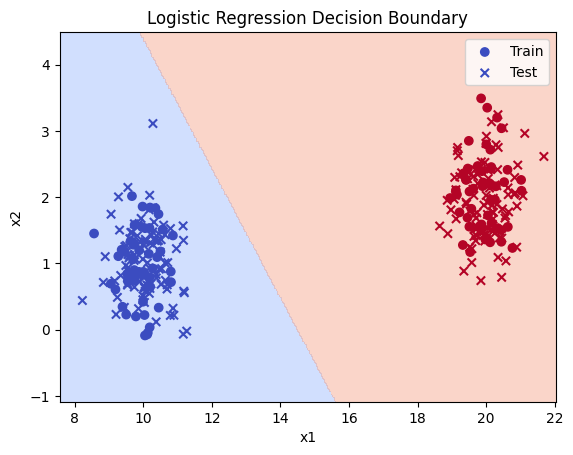

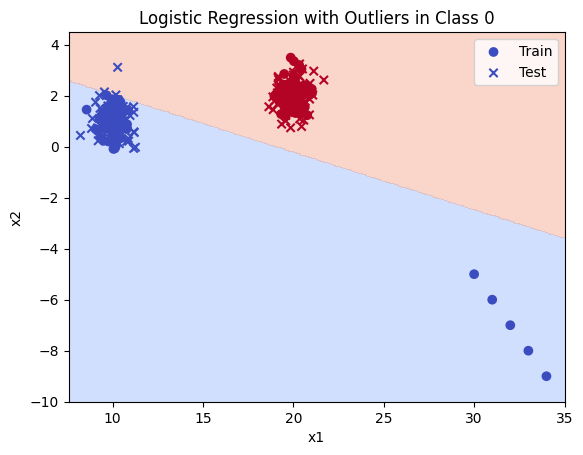

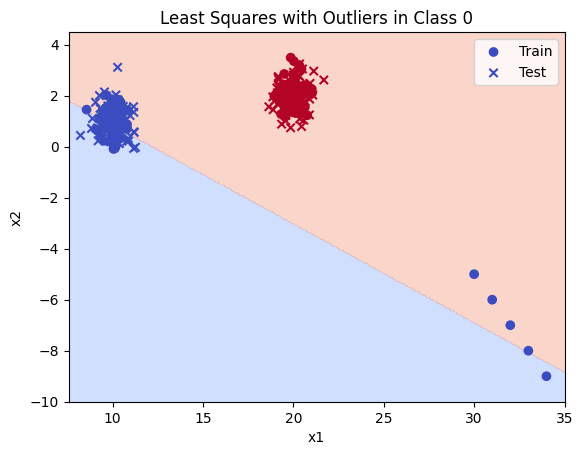

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# -----------------------------
# Part-a: Data Generation
# -----------------------------

# Means and covariance matrix for the two Gaussian classes
mu_class0 = [10, 1]
mu_class1 = [20, 2]
shared_cov = np.array([[0.3, 0], [0, 0.3]])

# Training data (50 per class)
train_0 = np.random.multivariate_normal(mu_class0, shared_cov, 50)
train_1 = np.random.multivariate_normal(mu_class1, shared_cov, 50)
X_train = np.vstack((train_0, train_1))
Y_train = np.array([0]*50 + [1]*50)

# Testing data (100 per class)
test_0 = np.random.multivariate_normal(mu_class0, shared_cov, 100)
test_1 = np.random.multivariate_normal(mu_class1, shared_cov, 100)
X_test = np.vstack((test_0, test_1))
Y_test = np.array([0]*100 + [1]*100)

# -----------------------------
# Part-b: Logistic Regression
# -----------------------------
def logistic_regression(train_X, train_Y, test_X, lr=0.01, max_iter=3000):
    def sigmoid(x):
        x = np.clip(x, -500, 500)
        return 1 / (1 + np.exp(-x))

    n_samples, n_features = train_X.shape
    X_aug = np.hstack((np.ones((n_samples, 1)), train_X))
    w = np.random.randn(n_features + 1) * 0.01

    for _ in range(max_iter):
        z = X_aug @ w
        pred = sigmoid(z)
        grad = X_aug.T @ (pred - train_Y) / n_samples
        w -= lr * grad

    test_aug = np.hstack((np.ones((test_X.shape[0], 1)), test_X))
    test_scores = sigmoid(test_aug @ w)
    test_labels = (test_scores >= 0.5).astype(int)
    return test_labels, w

Y_pred, w_final = logistic_regression(X_train, Y_train, X_test)

# -----------------------------
# Part-c: Accuracy Calculation
# -----------------------------
def compute_accuracy(true_labels, predicted_labels):
    return np.mean(true_labels == predicted_labels) * 100

acc = compute_accuracy(Y_test, Y_pred)
print(f"Accuracy (Logistic Regression): {acc:.2f}%")

# -----------------------------
# Part-d: Plot Decision Boundary
# -----------------------------
def plot_decision_boundary(X, y, w, X_test, y_test, title):
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_aug = np.hstack((np.ones((grid.shape[0], 1)), grid))

    def sigmoid(x): return 1 / (1 + np.exp(-x))

    probs = sigmoid(grid_aug @ w).reshape(xx.shape)
    plt.contourf(xx, yy, probs >= 0.5, alpha=0.4, cmap='coolwarm')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', label='Train')
    plt.scatter(X_test[:,0], X_test[:,1], c=y_test, marker='x', cmap='coolwarm', label='Test')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.show()

plot_decision_boundary(X_train, Y_train, w_final, X_test, Y_test,
                       title="Logistic Regression Decision Boundary")

# -----------------------------
# Part-e: Add Outliers and Compare
# -----------------------------

# Add outliers far from original Class 0 region
outlier_points = np.array([[30, -5], [31, -6], [32, -7], [33, -8], [34, -9]])
X_train_out = np.vstack((train_0, outlier_points, train_1))
Y_train_out = np.array([0]*(50+5) + [1]*50)

# Logistic Regression with outliers
Y_pred_out, w_out = logistic_regression(X_train_out, Y_train_out, X_test)
plot_decision_boundary(X_train_out, Y_train_out, w_out, X_test, Y_test,
                       title="Logistic Regression with Outliers in Class 0")

# Least Squares Classifier
def least_squares_classifier(X, y, test_X):
    X_aug = np.hstack((np.ones((X.shape[0], 1)), X))
    w_ls = np.linalg.pinv(X_aug.T @ X_aug) @ X_aug.T @ y
    test_aug = np.hstack((np.ones((test_X.shape[0], 1)), test_X))
    preds = test_aug @ w_ls
    return (preds >= 0.5).astype(int), w_ls

Y_pred_ls, w_ls = least_squares_classifier(X_train_out, Y_train_out, X_test)
plot_decision_boundary(X_train_out, Y_train_out, w_ls, X_test, Y_test,
                       title="Least Squares with Outliers in Class 0")


<b> Part (6) : Estimating the parameters of Gaussian Mixture Models (GMM) using Expectation-Maximization (EM) algorithm </b>


<dt> <b> a. Generating synthetic data : </b>  This part describes the steps involved in generating the synthetic data. </dt>


<dt>  1. Let us consider the GMM with Bivariate Gaussians   </dt>
<dd>  - Choose the appropriate means ($\mu$), covariances ($\Sigma$), and weights ($\pi$) of Bivariate Gaussian distributions. You may choose the following parameters for this asignment.  </dd>
<br>
<dt>  <center> $ \pi = \begin{bmatrix} 0.6  \\ 0.4 \end{bmatrix} \;\;\;\; \mu_{1} = \begin{bmatrix} -1.0  \\ -1.0 \end{bmatrix} \;\;\;\; \mu_{2} = \begin{bmatrix} 1.0  \\ 1.0 \end{bmatrix} \;\;\;\; $ </center>   </dd>
<br>
<dt>  <center> $ \Sigma_{1}^{full} = \begin{bmatrix} 0.15 & 0.1  \\ 0.1 & 0.25 \end{bmatrix} \;\;\;\; \Sigma_{2}^{full} = \begin{bmatrix} 0.3 & -0.25  \\ -0.25 & 0.25 \end{bmatrix}  $ </center>  </dd>
<br>
<dt>  <center> $ \Sigma_{1}^{diagonal} = \begin{bmatrix} 0.1 & 0.0  \\ 0.0 & 0.2 \end{bmatrix} \;\;\;\; \Sigma_{2}^{diagonal} = \begin{bmatrix} 0.2 & 0.0  \\ 0.0 & 0.1 \end{bmatrix}  $ </center>  </dd>
<br>
<dt>  <center> $ \Sigma_{1}^{spherical} = \begin{bmatrix} 0.2 & 0.0  \\ 0.0 & 0.2 \end{bmatrix} \;\;\;\; \Sigma_{2}^{spherical} = \begin{bmatrix} 0.1 & 0.0  \\ 0.0 & 0.1 \end{bmatrix}  $ </center>  </dd>

<dd>  - Pick one Gaussian following the selection probability as  $\pi$    </dd>
<dd>  - Sample the data point from the selected Bivariate Gaussian distribution    </dd>
<dd>  - Repeat the process N times to get the entire data set  </dd>
<dt>  2.Create the synthetic data set with the number of mixtures as 2.  </dt>
<dt>  3.Plot the synthetic data set with unique colors to the data points drawn from each Bivariate Gaussian distribution in GMM  </h4> </dt> </dd>

<dt> <b> b. Implementation of Expectation and Maximization (EM) algorithm : </b> This part focuses on implementing the EM algorithm from scratch to estimate the parameters of the Gaussian Mixture Model (GMM). </dt>  

<dt>  1. Chose the number of mixtures (M) and initialize the parameters of GMM model  </dt>
<dd>  - Make sure that the diagonal elements of covariance are positive, and the weights of Gaussians are positive and sum to 1 for satisfying the axioms of probability.  </dd>

<dt>   2. Expectation step :  Evaluate the responsibility of Gaussians in generating the data points using the current estimated parameters i.e $\hat\mu_{k}$ , $\hat\Sigma_{k}$ and $\hat\pi_{k}$, here k indicates the Gaussian in GMM  </dt>
<br>

<dd>  <center> $\gamma_{nk} = \frac{\pi_{k} N ( \textbf{x}_{n} / \mu_{k} , \Sigma_{k} )}{ \sum_{m=1}^{M} \pi_{m} N ( x_{n} / \mu_{m} , \Sigma_{m} ) }    \;\;\;\;\;\; ∀ \;\;k=1,2,...,M \;\; and \;\; n=1,2,...,N$  </center>  </dd>

<br>

<dd>   Where N is the total number of data points and M is the total number of Gaussians in GMM   </dd>

<dd>   - $\gamma_{nk}$ represents the responsibility of $k^{th}$ Gaussian in generating the $n^{th}$ data point   </dd>

<dd>   - $\sum_{n=1}^{N}$ $\gamma_{nk}$ represents the the effective number of data points generated by $k^{th}$ Gaussian   </dd>


<dt>   3. Maximization step :  Update the parameters ($\hat\mu_{k}$ , $\hat\Sigma_{k}$ and $\hat\pi_{k}$) of GMM using the current resosibilities ($\gamma_{nk}$) by maximizing the likelihood. </dt>

<dd>
 - Effective number of data points generated by $k^{th}$ Gaussian : $N_{k}$ = $\sum_{n=1}^{N}$ $\gamma_{nk}$   
 </dd>

<dd>
 - Mean of $k^{th}$ Gaussian : $\hat{\mu_{k}} = \frac{1}{N_{k}} \sum_{n=1}^{N}\gamma_{nk} x_{n}$   
 </dd>

<dd>
 - Covariance of $k^{th}$ Gaussian : $\hat{\Sigma_{k}} = \frac{1}{N_{k}} \sum_{n=1}^{N} \gamma_{nk} ( x_{n} - \hat{\mu_{k}} )( x_{n} - \hat{\mu_{k}} )^{T}$   
 </dd>

<dd>
 - Weight of $k^{th}$ Gaussian : $\hat{\pi_{k}} = \frac{N_{k}}{N}$  
 </dd>

<dt>  4. Compute the log-likelihood with the updated parameters  </dt>
<dt>   5. Repeat the expectation and maximization steps untill convergence  </dt>

<dt>  <b> c. Illustration of EM iterations </b>  </dt>

<dt>   5. Plot the contours of the estimated distributions over the iterations in the EM algorithm and overlay the data points.  </dt>

<dt>  <b> d. Understanding the issues with EM algorithm </b>  </dt>
<dt>   6. Check the influence of initialization on the convergence of the EM algorithm and fit quality.  </dt>
<dd>   - Demonstrate the observations with the plots mentioned in the "Illustration of EM iterations" section    </dd>
<dt>   6. Check the influence of the type of covariance matrix on the convergence of the EM algorithm and fit quality . </dt>
<dd>   - Execute the EM algorithm with different covariance matrices i.e Spherical, Diagonal and Full covariance  </dd>
<dd>   - Demonstrate the observations with the plots mentioned in the "Illustration of EM iterations" section  </dd>


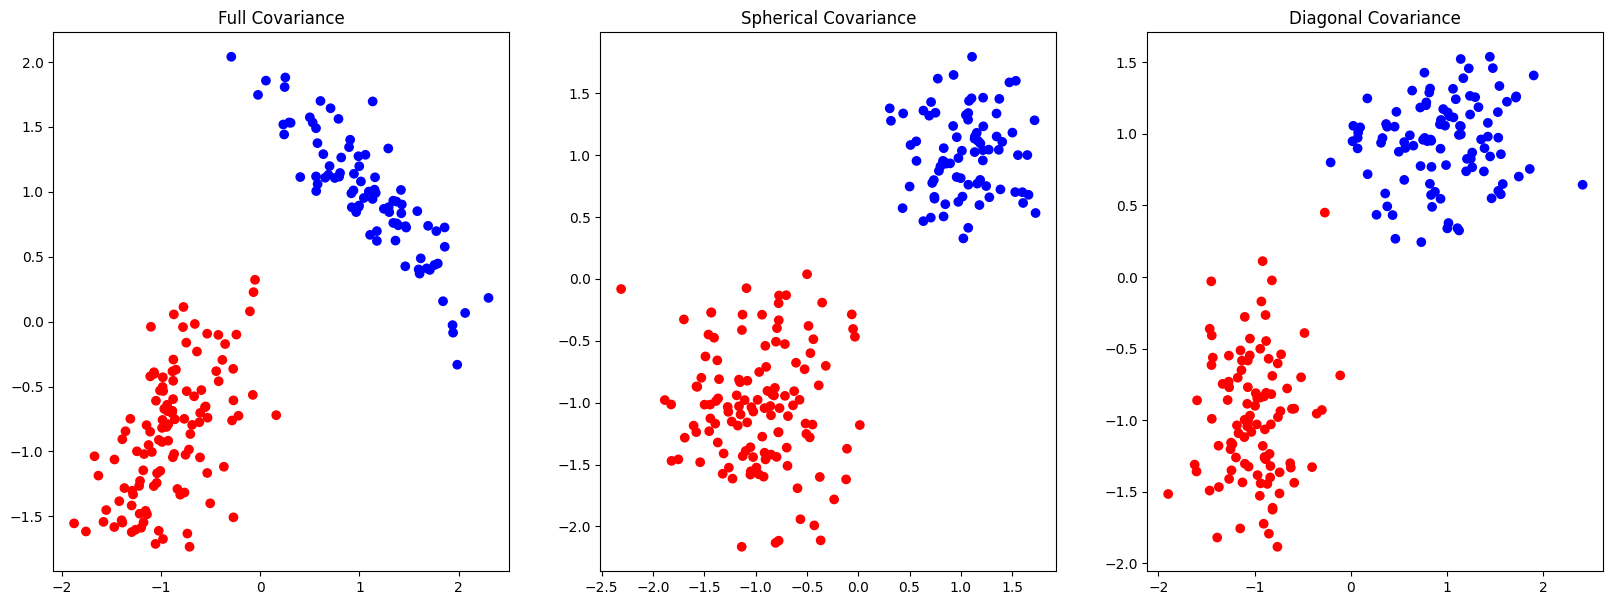

In [ ]:
# All imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random
import math

##########################################
# Part-6)-a: Generating synthetic data
##########################################

def generateData(pi, mu, sigma, N):
    data = []
    labels = []
    for _ in range(N):
        # Select Gaussian component
        k = random.choices(range(len(pi)), weights=pi)[0]
        # Sample from selected Gaussian
        sample = np.random.multivariate_normal(mu[k], sigma[k])
        data.append(sample)
        labels.append(k)
    return np.asarray(data), np.asarray(labels)

############################################################################
# Chose the appropriate means ($\mu$), covariances ($\Sigma$), and weights
############################################################################
mu1 = np.array([-1.0, -1.0])  # Mean vector of component1 in GMM
sig1 = np.array([[0.15, 0.1], [0.1, 0.25]])  # Full covariance matrix of component1 in GMM
mu2 = np.array([1.0, 1.0])    # Mean vector of component2 in GMM
sig2 = np.array([[0.3, -0.25], [-0.25, 0.25]])  # Full covariance matrix of component2 in GMM
pi = [0.6, 0.4]     # Prior probabilities

n_points = 200  # Number of points

# Spherical covariances
sig1_s = np.array([[0.2, 0.0], [0.0, 0.2]])
sig2_s = np.array([[0.1, 0.0], [0.0, 0.1]])
# Diagonal covariances
sig1_d = np.array([[0.1, 0.0], [0.0, 0.2]])
sig2_d = np.array([[0.2, 0.0], [0.0, 0.1]])

############################################################################
# Create the synthetic data set
############################################################################
data_full, labels_full = generateData(pi, [mu1, mu2], [sig1, sig2], n_points)
data_sp, labels_sp = generateData(pi, [mu1, mu2], [sig1_s, sig2_s], n_points)
data_dg, labels_dg = generateData(pi, [mu1, mu2], [sig1_d, sig2_d], n_points)

############################################################################
# Plot the synthetic data set
############################################################################
fig, ax = plt.subplots(1, 3, figsize=(20, 7))

# Visualize the data sampled from the GMM with full covariance matrix
ax[0].scatter(data_full[:, 0], data_full[:, 1], c=labels_full, cmap=ListedColormap(['red', 'blue']))
ax[0].set_title('Full Covariance')

# Visualize the data sampled from the GMM with spherical covariance matrix
ax[1].scatter(data_sp[:, 0], data_sp[:, 1], c=labels_sp, cmap=ListedColormap(['red', 'blue']))
ax[1].set_title('Spherical Covariance')

# Visualize the data sampled from the GMM with diagonal covariance matrix
ax[2].scatter(data_dg[:, 0], data_dg[:, 1], c=labels_dg, cmap=ListedColormap(['red', 'blue']))
ax[2].set_title('Diagonal Covariance')

plt.show()


Iteration 1, Log-likelihood: -558.33


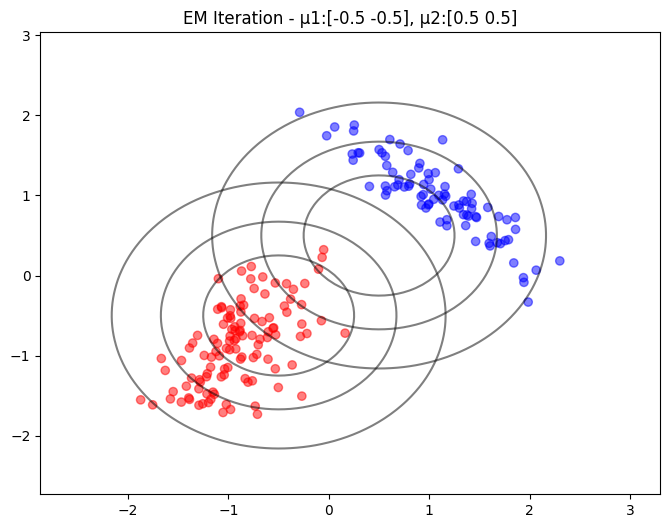

Iteration 2, Log-likelihood: -450.56


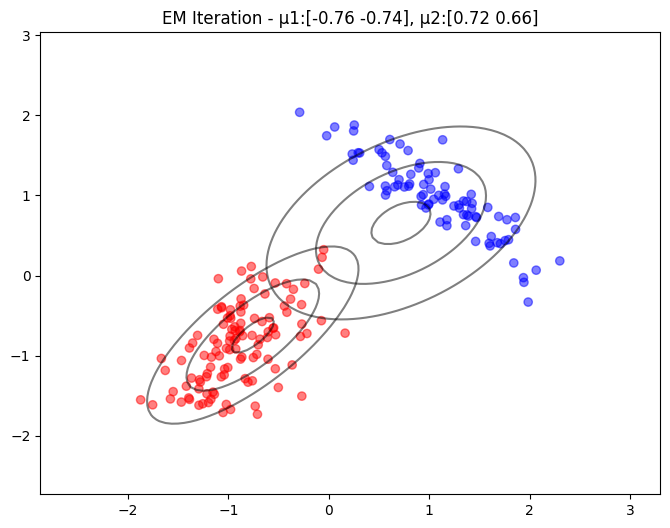

Iteration 3, Log-likelihood: -401.25


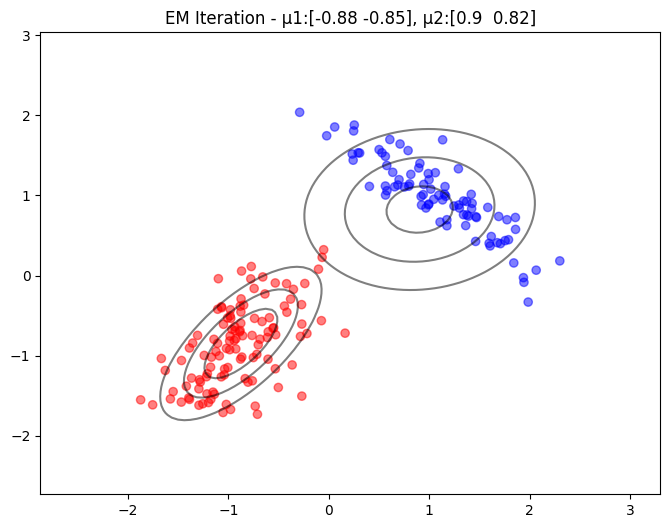

Iteration 4, Log-likelihood: -344.72


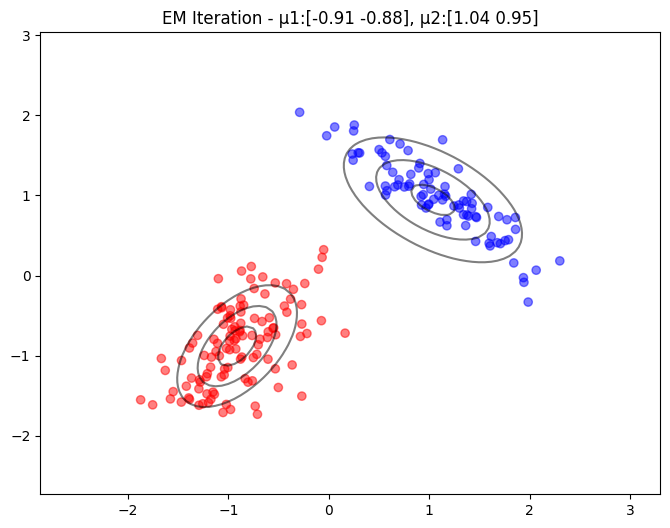

Iteration 5, Log-likelihood: -312.82


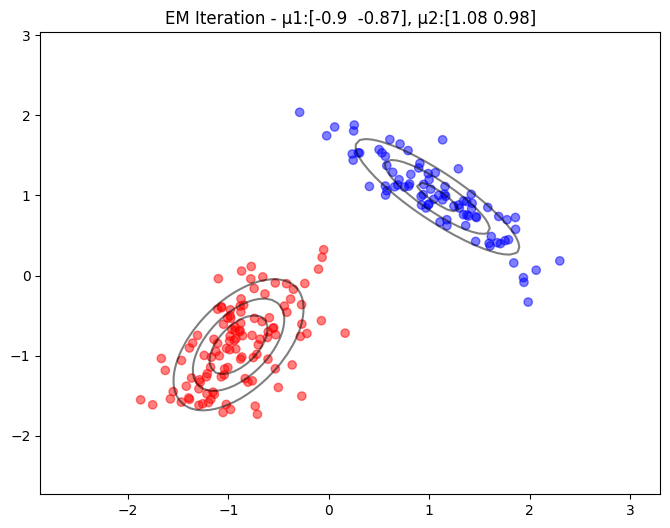

Iteration 6, Log-likelihood: -312.71


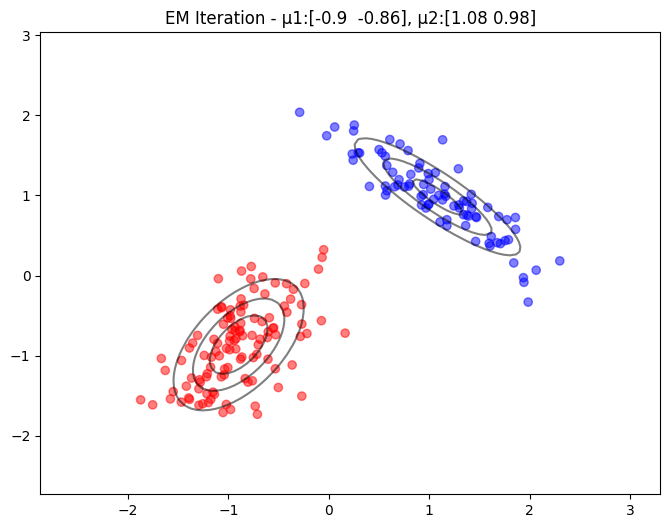

Iteration 7, Log-likelihood: -312.71


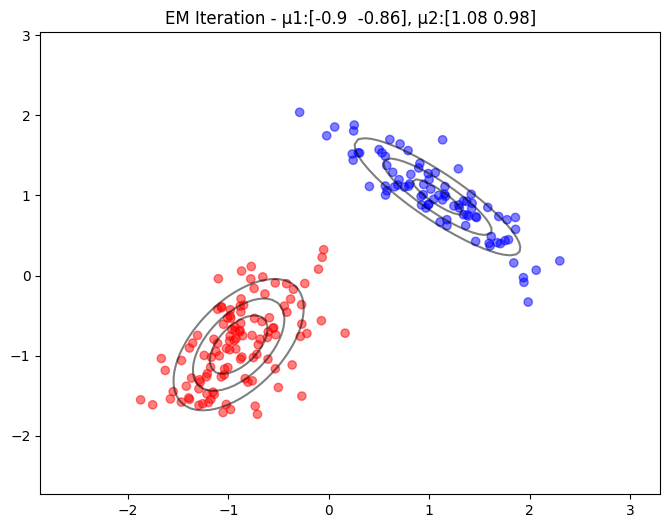

Iteration 8, Log-likelihood: -312.71


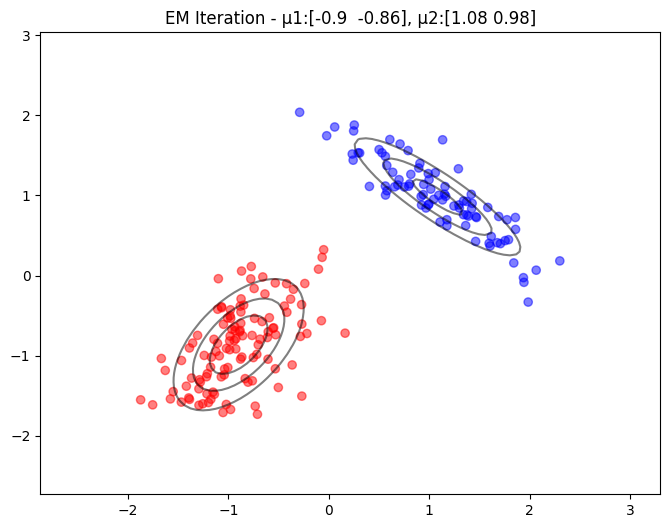

Iteration 9, Log-likelihood: -312.71


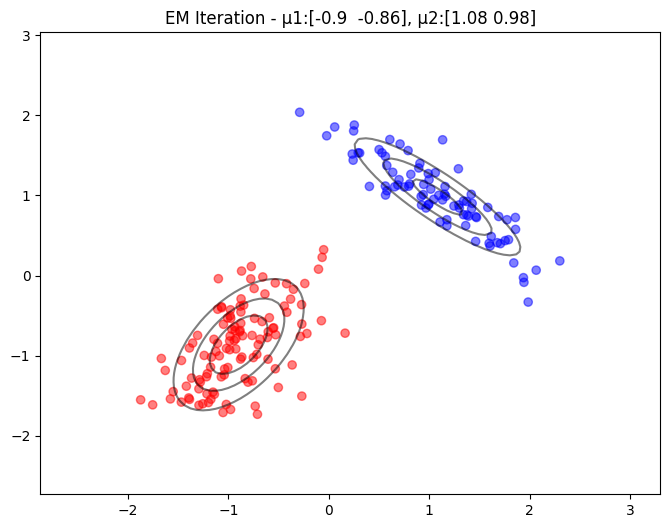

Iteration 10, Log-likelihood: -312.71


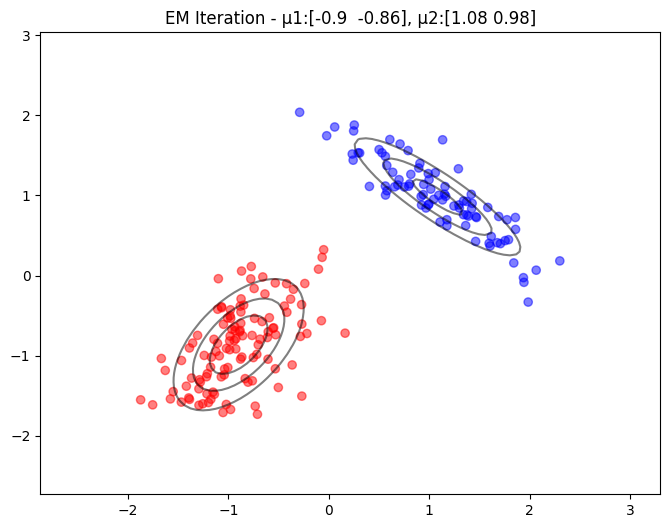

In [ ]:
import numpy as np
import pandas as pd
import random as rand
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal
import sys
import math
##########################################
# Part-6)-b: Implementation of EM algorithm
##########################################

def likelihood(data, pi, mu, sigma, log_likelihood=False, likelihoods=False):
    N = len(data)
    M = len(pi)
    prob = np.zeros((N, M))

    for k in range(M):
        prob[:, k] = pi[k] * multivariate_normal.pdf(data, mean=mu[k], cov=sigma[k])

    if likelihoods:
        return prob
    total_prob = np.sum(prob, axis=1)
    if log_likelihood:
        return np.sum(np.log(total_prob))
    return total_prob

def expectation(data, pi, mu, sigma):
    N = len(data)
    M = len(pi)
    gamma = np.zeros((N, M))

    prob = likelihood(data, pi, mu, sigma, likelihoods=True)
    denominator = np.sum(prob, axis=1).reshape(-1, 1)
    gamma = prob / denominator

    return gamma

def maximization(data, gamma):
    N = len(data)
    M = gamma.shape[1]

    # Effective number of points per component
    N_k = np.sum(gamma, axis=0)

    # Update pi
    pi = N_k / N

    # Update mu
    mu = []
    for k in range(M):
        mu_k = np.sum(gamma[:, k].reshape(-1, 1) * data, axis=0) / N_k[k]
        mu.append(mu_k)

    # Update sigma
    sigma = []
    for k in range(M):
        diff = data - mu[k]
        sigma_k = np.dot(gamma[:, k] * diff.T, diff) / N_k[k]
        sigma.append(sigma_k)

    return pi, np.array(mu), sigma

def plot_contours(data, labels, pi, mu, sigma):
    plt.figure(figsize=(8, 6))
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap=ListedColormap(['red', 'blue']), alpha=0.5)

    # Create grid for contour plot
    x = np.linspace(min(data[:, 0])-1, max(data[:, 0])+1, 100)
    y = np.linspace(min(data[:, 1])-1, max(data[:, 1])+1, 100)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))

    # Plot contours for each component
    for k in range(len(pi)):
        rv = multivariate_normal(mu[k], sigma[k])
        Z = rv.pdf(pos)
        plt.contour(X, Y, Z, levels=3, colors='black', alpha=0.5)

    plt.title(f'EM Iteration - μ1:{mu[0].round(2)}, μ2:{mu[1].round(2)}')
    plt.show()

############################################################################
# Run EM algorithm
############################################################################
data = data_full  # data to run EM-algorithm
labels = labels_full  # labels
N = len(data)  # number of input examples
D = data.shape[1]  # data dimension
M = 2  # no.of components in GMM

# Initialize parameters
pi = np.array([0.5, 0.5])  # Initialize the prior probabilities
mu = [np.array([-0.5, -0.5]), np.array([0.5, 0.5])]  # Initialize the mean vectors
sigma = [np.eye(D), np.eye(D)]  # Initialize the covariance matrices

nsteps = 10  # Number of steps to run EM algorithm
for index in range(nsteps):
    # Compute the likelihood
    ll = likelihood(data, pi, mu, sigma, log_likelihood=True)
    print(f"Iteration {index+1}, Log-likelihood: {ll:.2f}")

    # Plot the contours
    plot_contours(data, labels, pi, mu, sigma)

    # Expectation step
    gamma = expectation(data, pi, mu, sigma)

    # Maximization step
    pi, mu, sigma = maximization(data, gamma)



Testing different initializations:

Initialization 1:
Iteration 1, Log-likelihood: -450.56
Iteration 2, Log-likelihood: -401.25
Iteration 3, Log-likelihood: -344.72
Iteration 4, Log-likelihood: -312.82
Iteration 5, Log-likelihood: -312.71
Iteration 6, Log-likelihood: -312.71
Iteration 7, Log-likelihood: -312.71
Iteration 8, Log-likelihood: -312.71
Iteration 9, Log-likelihood: -312.71
Iteration 10, Log-likelihood: -312.71


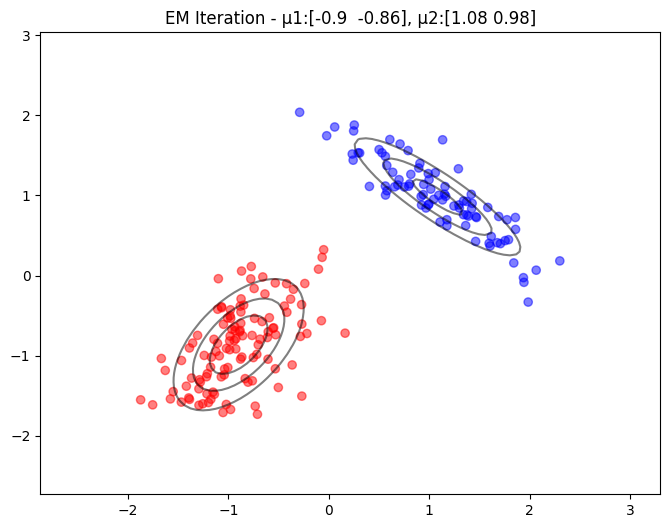


Initialization 2:
Iteration 1, Log-likelihood: -483.74
Iteration 2, Log-likelihood: -479.23
Iteration 3, Log-likelihood: -477.37
Iteration 4, Log-likelihood: -475.99
Iteration 5, Log-likelihood: -474.59
Iteration 6, Log-likelihood: -473.05
Iteration 7, Log-likelihood: -471.24
Iteration 8, Log-likelihood: -468.92
Iteration 9, Log-likelihood: -465.51
Iteration 10, Log-likelihood: -459.41


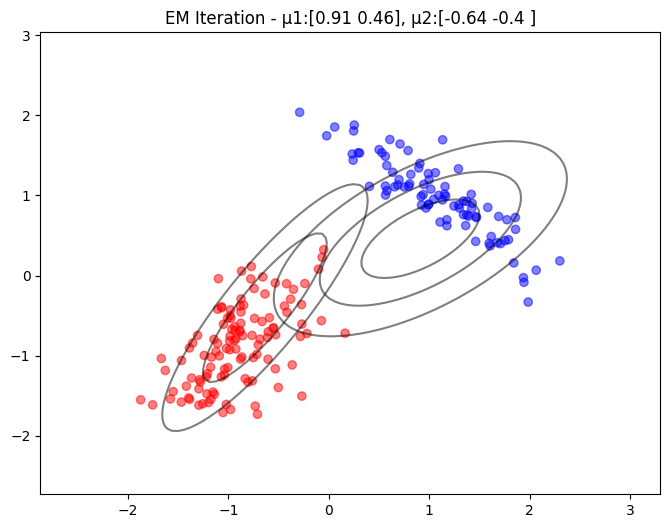


Initialization 3:
Iteration 1, Log-likelihood: -490.93
Iteration 2, Log-likelihood: -484.18
Iteration 3, Log-likelihood: -479.48
Iteration 4, Log-likelihood: -476.87
Iteration 5, Log-likelihood: -474.94
Iteration 6, Log-likelihood: -472.82
Iteration 7, Log-likelihood: -469.81
Iteration 8, Log-likelihood: -464.26
Iteration 9, Log-likelihood: -450.14
Iteration 10, Log-likelihood: -406.31


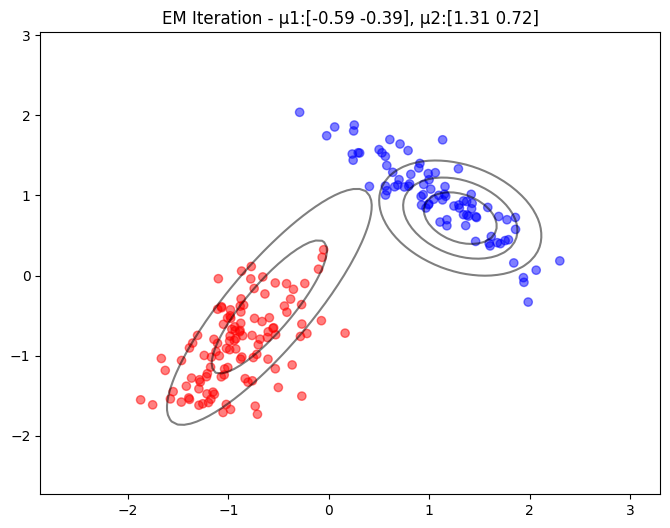


Testing different covariance types:

Covariance type: full
Iteration 1, Log-likelihood: -450.56
Iteration 2, Log-likelihood: -401.25
Iteration 3, Log-likelihood: -344.72
Iteration 4, Log-likelihood: -312.82
Iteration 5, Log-likelihood: -312.71
Iteration 6, Log-likelihood: -312.71
Iteration 7, Log-likelihood: -312.71
Iteration 8, Log-likelihood: -312.71
Iteration 9, Log-likelihood: -312.71
Iteration 10, Log-likelihood: -312.71


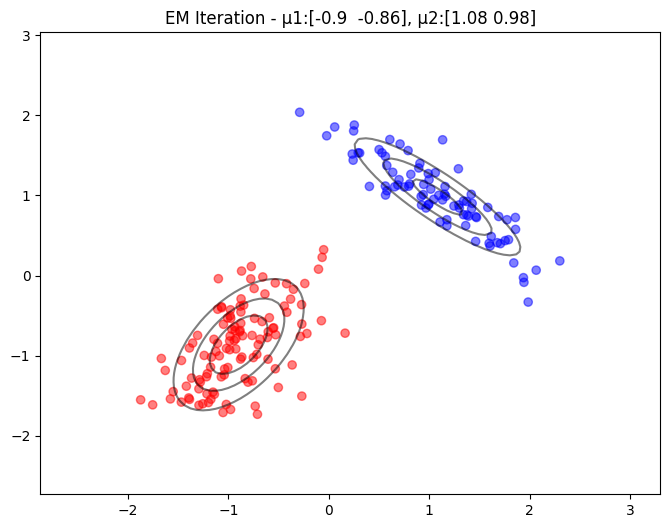


Covariance type: diag
Iteration 1, Log-likelihood: -404.92
Iteration 2, Log-likelihood: -393.65
Iteration 3, Log-likelihood: -393.46
Iteration 4, Log-likelihood: -393.45
Iteration 5, Log-likelihood: -393.45
Iteration 6, Log-likelihood: -393.45
Iteration 7, Log-likelihood: -393.45
Iteration 8, Log-likelihood: -393.45
Iteration 9, Log-likelihood: -393.45
Iteration 10, Log-likelihood: -393.45


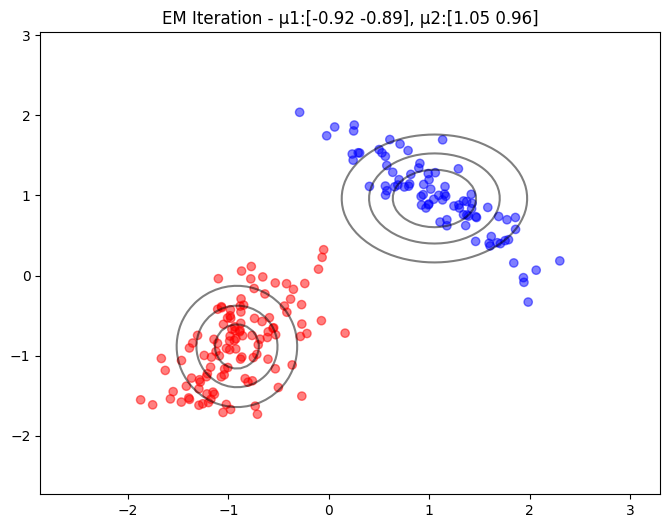


Covariance type: spherical
Iteration 1, Log-likelihood: -408.47
Iteration 2, Log-likelihood: -397.60
Iteration 3, Log-likelihood: -397.41
Iteration 4, Log-likelihood: -397.40
Iteration 5, Log-likelihood: -397.40
Iteration 6, Log-likelihood: -397.40
Iteration 7, Log-likelihood: -397.40
Iteration 8, Log-likelihood: -397.40
Iteration 9, Log-likelihood: -397.40
Iteration 10, Log-likelihood: -397.40


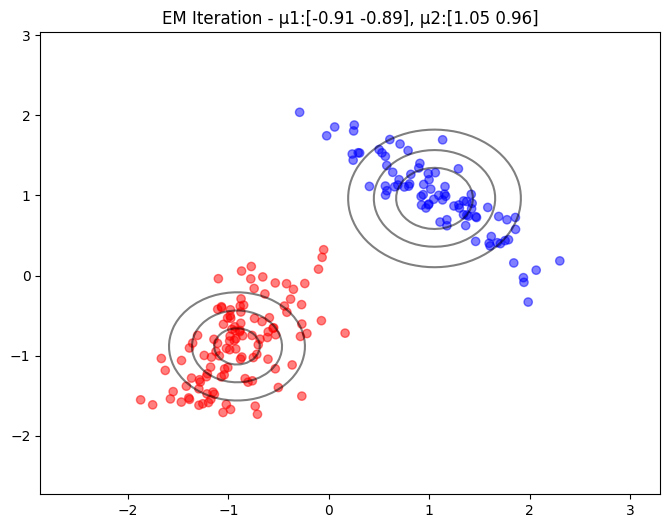

In [ ]:

##########################################
# Part-6)-d: Understand issues with EM
##########################################
# Initialization sensitivity
print("\nTesting different initializations:")
for init in range(3):
    print(f"\nInitialization {init+1}:")
    if init == 0:
        mu = [np.array([-0.5, -0.5]), np.array([0.5, 0.5])]
    elif init == 1:
        mu = [np.array([1.0, -1.0]), np.array([-1.0, 1.0])]
    else:
        mu = [np.array([0.0, 0.0]), np.array([1.0, -1.0])]

    sigma = [np.eye(D), np.eye(D)]
    pi = np.array([0.5, 0.5])

    for index in range(nsteps):
        gamma = expectation(data, pi, mu, sigma)
        pi, mu, sigma = maximization(data, gamma)
        ll = likelihood(data, pi, mu, sigma, log_likelihood=True)
        print(f"Iteration {index+1}, Log-likelihood: {ll:.2f}")

    plot_contours(data, labels, pi, mu, sigma)

# Covariance type comparison
print("\nTesting different covariance types:")
for cov_type in ['full', 'diag', 'spherical']:
    print(f"\nCovariance type: {cov_type}")
    mu = [np.array([-0.5, -0.5]), np.array([0.5, 0.5])]
    pi = np.array([0.5, 0.5])

    if cov_type == 'full':
        sigma = [np.eye(D), np.eye(D)]
    elif cov_type == 'diag':
        sigma = [np.diag([0.5, 0.5]), np.diag([0.5, 0.5])]
    else:  # spherical
        sigma = [0.5*np.eye(D), 0.5*np.eye(D)]

    for index in range(nsteps):
        gamma = expectation(data, pi, mu, sigma)
        pi, mu, sigma = maximization(data, gamma)

        if cov_type == 'diag':
            sigma = [np.diag(np.diag(s)) for s in sigma]
        elif cov_type == 'spherical':
            sigma = [np.eye(D)*np.mean(np.diag(s)) for s in sigma]

        ll = likelihood(data, pi, mu, sigma, log_likelihood=True)
        print(f"Iteration {index+1}, Log-likelihood: {ll:.2f}")

    plot_contours(data, labels, pi, mu, sigma)






<b> Report your observations </b>

1.The EM algorithm is sensitive to initialization - different starting points can lead to different local optima, as seen in the varying convergence patterns with different initial mean values.

2.The type of covariance matrix significantly affects the model's flexibility - full covariance captures correlations but may overfit, while diagonal/spherical constraints provide regularization but may underfit complex distributions.

3.The log-likelihood consistently increases with each EM iteration, demonstrating the algorithm's monotonic convergence property, though the rate of improvement diminishes as it approaches a local optimum.